# Causal Analysis of Bitcoin Price Drivers

**PI2 Industrial Innovation Project** — ESILV x Ginjer Asset Management  
**Partner:** Mathieu Vaissié (Ginjer-AM)

---

## Theoretical Framework

This notebook implements **López de Prado's 3-step scientific method for causal factor investing** ("Causal Factor Investing", 2023), applied to Bitcoin price modeling using **Vaissié's 3-pillar data categorization** ("Bitcoin, un actif comme les autres?", 2021).

### Why Causal Inference?

Traditional factor investing suffers from **Type-B spuriosity** (López de Prado): noncausal associations caused by confounding variables. A correlation between feature X and BTC returns may exist in historical data but will not persist under intervention if the true causal structure is misunderstood. Every factor model makes **implicit causal claims** (choosing Y = Xβ + ε implies X causes Y), yet most studies never test these claims.

The **do-operator** (Pearl) distinguishes:
- **Conditioning** (observation): P[Y | X = x] — what Y looks like *when we happen to see* X = x
- **Intervention** (causation): P[Y | do(X = x)] — what Y looks like *when we set* X to x

Only interventional relationships are stable under regime changes and useful for portfolio construction.

### The 3-Step Method

| Step | Name | Goal | Methods Used Here |
|------|------|------|-------------------|
| 1 | **Phenomenological** | Observe statistical associations (P[X,Y] ≠ P[X]P[Y]) | Stationarity tests (ADF+KPSS), correlation heatmaps |
| 2 | **Theoretical** | Propose a causal DAG consistent with observations | PC Algorithm, NOTEARS, PCMCI, Granger Causality |
| 3 | **Falsification** | Test if P[Y|do(X)] ≠ P[Y] via refutation | DoWhy ATE + placebo/random-cause/subset tests |

### Vaissié's 3-Pillar Categorization

Vaissié identifies three categories of Bitcoin price drivers, each dominant at different time horizons:

| Pillar | Description | Key Variables | Dominant Horizon |
|--------|-------------|---------------|------------------|
| **On-Chain** | Blockchain-native metrics reflecting network health, adoption, and miner economics | MVRV, HashRate, AdrActCnt, NVT, miner_revenue | Medium-term (weeks to months) |
| **Macro** | Traditional financial indicators: rates, equities, volatility, currencies, liquidity | VIX, DXY, SPX, yield curves, M2, FARBAST | Long-term (months+) |
| **Sentiment** | Market psychology and crypto-specific demand signals | Fear & Greed Index, exchange balances, stablecoin supply, Google Trends keywords | Short-term (days to weeks) |

---

## Section 0 — Setup & Data Loading

In [1]:
# ============================================================
# IMPORTS & CONFIGURATION
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.stattools import adfuller, kpss, grangercausalitytests

# ---- Target ----
# XBTUSD Curncy is the Bloomberg ticker for Bitcoin price in USD.
# This is our OUTCOME variable — it must NEVER appear as a causal feature.
BTC_TICKER = "XBTUSD Curncy"

# ---- Analysis parameters ----
START_DATE = "2015-01-01"   # Start date for analysis (Bitcoin maturity threshold)
ALPHA = 0.05                # Significance level for all statistical tests

# ============================================================
# VAISSIÉ'S 3-PILLAR CATEGORIZATION
# ============================================================
# Each feature is categorized according to Vaissié's framework.
# Source: "Bitcoin, un actif comme les autres?" (Vaissié, 2021)
#
# IMPORTANT NOTES:
# - Altcoin prices (XETUSD=ETH, XBNUSD=BNB, XRPUSD=XRP, XLCUSD=LTC)
#   come from the Bloomberg 'Alternatives' sheet, NOT the Sentiment sheet.
#   They are crypto market indicators, categorized under 'Crypto Market'.
# - The Sentiment sheet contains: fear_and_greed, btc_balance_on_exchanges,
#   total_stablecoin_mcap, btc_dominance_proxy, and 50 Google Trends keywords
#   (e.g., 'Bitcoin', 'Coinbase', 'BlackRock Bitcoin', 'FOMO', 'HODL', etc.)
# - price_usd and market_cap_usd are derived from BTC price — including them
#   as "causes" of BTC would be tautological. They are excluded from causal tests.

FEATURE_CATEGORIES = {
    # Pillar 1: On-Chain (blockchain-native data from CoinMetrics/Blockchain.com)
    # These reflect network health, adoption cycles, and miner economics.
    # Vaissié: "most important at medium-term horizons (weeks to months)"
    'On-Chain': [
        'HashRate',              # Total network computational power (TH/s)
        'AdrActCnt',             # Active addresses per day (adoption proxy)
        'TxCnt',                 # Transaction count per day
        'TxTfrCnt',              # Transfer count (excl. change outputs)
        'CapMVRVCur',            # MVRV = Market Value / Realized Value (key Vaissié metric)
        'NVT',                   # Network Value to Transactions ratio
        'NVT_Signal',            # Smoothed NVT (Woo's signal)
        'SplyCur',               # Current circulating supply
        'mining_difficulty',     # Network difficulty adjustment
        'miner_revenue_usd',     # Total miner revenue (block reward + fees)
        'hashrate_7d_pct',       # 7-day hash rate change (%)
        'tx_fees_usd',           # Total transaction fees in USD
        'est_tx_volume_usd',     # Estimated on-chain transaction volume
        'avg_block_size',        # Average block size (bytes)
        'mempool_count',         # Pending transactions in mempool
        'mempool_growth',        # Mempool growth rate
        'utxo_count',            # Unspent transaction outputs
        'active_addr_ratio',     # Active addresses / total addresses
        'difficulty_14d_pct',    # 14-day difficulty change
        'cost_per_tx_usd',       # Average cost per transaction
        'tx_per_second',         # Transactions per second
        'n_tx_excl_popular',     # Transactions excluding popular addresses
        'mempool_size_bytes',    # Mempool size in bytes
        'ln_channel_count',      # Lightning Network channels
        'ln_capacity_sat',       # Lightning Network capacity (satoshis)
        'btc_commits_weekly',    # GitHub commits to Bitcoin Core
        'days_to_next_halving',  # Days until next supply halving event
        'days_since_halving',    # Days since last halving
    ],
    
    # Pillar 2: Macro (traditional finance from Bloomberg)
    # These reflect the global monetary/financial environment.
    # Vaissié: "interest rates dominate macro influences; most important at longer horizons"
    'Macro': [
        'VIX Index',             # CBOE Volatility Index (equity fear gauge)
        'MOVE Index',            # Bond market volatility (Merrill Lynch)
        'DXY Curncy',            # US Dollar Index (trade-weighted)
        'SPX Index',             # S&P 500
        'CCMP Index',            # Nasdaq Composite
        'RTY Index',             # Russell 2000 (small caps)
        'XAU Curncy',            # Gold price
        'M2 Index',              # US M2 money supply (liquidity)
        'ECMAM2 Index',          # Eurozone M2 money supply
        'USYC2Y10 Index',        # US 2y-10y yield curve slope
        'DEYC2Y10 Index',        # Germany 2y-10y yield curve
        'USGG3M Index',          # US 3-month Treasury yield
        'EURUSD Curncy',         # EUR/USD exchange rate
        'JPYUSD Curncy',         # JPY/USD exchange rate
        'CNH Curncy',            # Offshore Chinese Yuan
        'FARBAST Index',         # Fed Funds rate - carry trade proxy
        'LUATTRUU Index',        # Bloomberg US Aggregate Bond Index
        'IUTPELC Index',         # US Initial Jobless Claims
        'CL1 COMB Comdty',       # WTI Crude Oil front month
        'NG1 COMB Comdty',       # Natural Gas front month
        'CPEXEMUY Index',        # US Core PCE (inflation)
        'CESIUSD Index',         # Citi Economic Surprise - US
        'CESIJPY Index',         # Citi Economic Surprise - Japan
        'TFF2RLFD Index',        # CFTC Futures positioning - leveraged funds
        'TFF2RAIN Index',        # CFTC Futures positioning - asset managers
        'TFC2RORS Index',         # CFTC Futures - other reportables
        'TFC2RLFS Index',        # CFTC Futures - leveraged funds (combined)
        'CFC5ROIN Index',        # CFTC Futures - other institutional
    ],
    
    # Pillar 3: Sentiment (from Alternative.me API, Google Trends, CoinMetrics)
    # These capture market psychology, retail interest, and crypto-native demand.
    # Vaissié: "most important at short-term horizons (days to weeks)"
    # NOTE: The Sentiment sheet in the Excel contains:
    #   - fear_and_greed (Alternative.me index, 0-100)
    #   - btc_balance_on_exchanges (supply on centralized exchanges)
    #   - total_stablecoin_mcap (USDT+USDC market cap — demand proxy)
    #   - btc_dominance_proxy (BTC market cap / total crypto market cap)
    #   - 50 Google Trends keywords (weekly search interest, 0-100)
    'Sentiment': [
        'fear_and_greed',           # Alternative.me Fear & Greed Index
        'btc_balance_on_exchanges', # BTC held on exchanges (selling pressure proxy)
        'total_stablecoin_mcap',    # Total stablecoin market cap (dry powder)
        'btc_dominance_proxy',       # BTC dominance proxy
        # Google Trends keywords (selected high-signal ones)
        'Bitcoin',                  # Generic search interest
        'Coinbase',                 # Exchange interest (retail onboarding)
        'BlackRock Bitcoin',        # Institutional interest proxy
        'Bitcoin Halving',          # Halving awareness
        'Buy Bitcoin',              # Direct purchase intent
        'FOMO',                     # Fear of missing out
        'HODL',                     # Hold sentiment
        'Bull Run',                 # Bullish sentiment
        'Bear Market',              # Bearish sentiment
        'Crypto',                   # General crypto interest
        'Bitcoin Mining',           # Mining interest
        'Recession',               # Macro fear keyword
        'Inflation',               # Inflation hedge narrative
        'Interest Rates',          # Rate sensitivity awareness
    ],
    
    # Crypto Market: Altcoin prices from Bloomberg Alternatives sheet
    # These are NOT sentiment — they are correlated crypto assets.
    # They may act as proxies for broad crypto market beta.
    'Crypto Market': [
        'XETUSD Curncy',   # Ethereum (ETH/USD)
        'XBNUSD Curncy',   # Binance Coin (BNB/USD)
        'XRPUSD Curncy',   # Ripple (XRP/USD)
        'XLCUSD Curncy',   # Litecoin (LTC/USD)
    ],
}

# Variables that are DERIVED from BTC price — must be excluded from causal features
# Including these as "causes" would be tautological (they ARE the price)
BTC_DERIVED = {'price_usd', 'market_cap_usd', BTC_TICKER}

def get_category(ticker):
    """Return the Vaissié category for a given ticker."""
    for cat, tickers in FEATURE_CATEGORIES.items():
        if ticker in tickers:
            return cat
    return 'Other'

CATEGORY_COLORS = {
    'On-Chain': '#27ae60',      # Forest green
    'Macro': '#2980b9',         # Strong blue
    'Sentiment': '#e74c3c',     # Red
    'Crypto Market': '#8e44ad', # Deep purple
    'Other': '#7f8c8d',         # Gray
}

print('Setup complete.')

Setup complete.


In [2]:
# ============================================================
# LOAD DATA FROM BLOOMBERG EXCEL
# ============================================================
# The file indicatorsMY_v02.xlsx is a multi-sheet Bloomberg export (22MB).
# Each sheet has a different format:
#   - 'Alternatives' etc: Ticker | Variable | Date columns (FORMAT A)
#   - 'Sentiment', 'OnChain': Date | Feature columns (FORMAT B)

sheets = pd.read_excel("indicatorsMY_v02.xlsx", sheet_name=None)
print(f"Sheets loaded: {list(sheets.keys())}")
for name, sheet in sheets.items():
    print(f"  {name}: {sheet.shape}")

Sheets loaded: ['Alternatives', 'Market_Indicators', 'Price_Level_BTC', 'Open_Interests_Futures', 'Money_Supply', 'Central_Banks_Balance_Sheets', 'Central_Banks_Policy_Rates', 'TED_Spreads', '3M_Gov__Bonds', 'Yield_Curve', 'Foreign_Exchange', 'Miscellaneous', 'Gross_Domestic_Products', 'Industrial_Production', 'Retail_Sales', 'Inflation', 'Economic Policy Uncertainty', 'News Based Policy Uncertainty', 'Economic_Surprises', 'Semiconductor_Market_Dynamics', 'Sentiment', 'OnChain']
  Alternatives: (136, 5869)
  Market_Indicators: (58, 5870)
  Price_Level_BTC: (10, 5870)
  Open_Interests_Futures: (125, 5870)
  Money_Supply: (28, 5870)
  Central_Banks_Balance_Sheets: (28, 5871)
  Central_Banks_Policy_Rates: (28, 7308)
  TED_Spreads: (16, 5871)
  3M_Gov__Bonds: (20, 5870)
  Yield_Curve: (20, 5871)
  Foreign_Exchange: (15, 5870)
  Miscellaneous: (25, 5870)
  Gross_Domestic_Products: (28, 5870)
  Industrial_Production: (28, 5870)
  Retail_Sales: (28, 5870)
  Inflation: (28, 5870)
  Economic Po

In [3]:
# ============================================================
# PARSE & MERGE ALL SHEETS
# ============================================================
# CRITICAL FIX (Bug A from CausalityTest.ipynb):
# The original notebook had: .str.replace("-", "")
# This SILENTLY DESTROYED ALL NEGATIVE VALUES (e.g., -2.5 -> 2.5)
# affecting VIX changes, yield curve slopes, sentiment shifts, etc.
# FIX: Use pd.to_numeric() directly — it handles all formats correctly.

DEFAULT_VAR = "px_last"
df_list = []

for name, sheet in sheets.items():
    sheet = sheet.dropna(how='all', axis=0).dropna(how='all', axis=1)
    if sheet.shape[1] < 3:
        continue

    a1 = str(sheet.columns[0]).strip().lower()
    b1 = str(sheet.columns[1]).strip().upper()

    # FORMAT A: Ticker | Variable | Date columns (e.g., Alternatives, Carry)
    if b1 == "DATES":
        tmp = sheet.copy()
        tmp.columns = ["Ticker", "Variable"] + list(tmp.columns[2:])
        tmp["Variable"] = tmp["Variable"].astype(str).str.strip()
        tmp = tmp[tmp["Variable"] == DEFAULT_VAR]  # Keep only px_last
        if tmp.empty:
            continue
        melted = tmp.melt(id_vars=["Ticker", "Variable"], var_name="Date", value_name="Value")

    # FORMAT B: Date | Feature columns (Sentiment, OnChain, Indices)
    elif a1 == "date":
        tmp = sheet.copy()
        tmp = tmp.rename(columns={tmp.columns[0]: "Ticker"})
        tmp.insert(1, "Variable", DEFAULT_VAR)
        melted = tmp.melt(id_vars=["Ticker", "Variable"], var_name="Date", value_name="Value")

    else:
        continue

    # ---- Cleaning (BUG A FIX: pd.to_numeric preserves negatives) ----
    melted["Date"] = pd.to_datetime(melted["Date"], errors="coerce")
    melted["Value"] = pd.to_numeric(melted["Value"], errors="coerce")
    melted = melted.dropna(subset=["Date", "Value"])
    melted["Ticker"] = melted["Ticker"].astype(str).str.strip()
    melted["Variable"] = DEFAULT_VAR
    melted["Category"] = name
    # Strip timezone PER CHUNK to avoid mixed tz after concat
    # (Sentiment dates are UTC-aware; others are tz-naive.
    #  Mixing them in concat produces object dtype → dt accessor fails)
    if melted["Date"].dt.tz is not None:
        melted["Date"] = melted["Date"].dt.tz_localize(None)
    df_list.append(melted)

merged_df = pd.concat(df_list, ignore_index=True)

# Force timezone-naive dates (some Bloomberg exports include tz info)
merged_df["Date"] = pd.to_datetime(merged_df["Date"], errors="coerce")
merged_df["Date"] = merged_df["Date"].dt.tz_localize(None)

print(f"Total tickers: {merged_df['Ticker'].nunique()}")
print(f"Date range: {merged_df['Date'].min()} to {merged_df['Date'].max()}")

# VERIFY: negative values preserved (this would fail with the old hyphen-stripping bug)
n_neg = (merged_df['Value'] < 0).sum()
print(f"\nNegative values in dataset: {n_neg}")
print("(Must be > 0 — yield curve slopes, VIX changes, economic surprises can be negative)")
assert n_neg > 0, "BUG: No negative values found — data cleaning may be stripping hyphens!"

Total tickers: 200
Date range: 1900-01-01 00:00:00 to 2026-01-18 00:00:00

Negative values in dataset: 21341
(Must be > 0 — yield curve slopes, VIX changes, economic surprises can be negative)


In [4]:
# ============================================================
# PIVOT TABLE & FEATURE CATEGORIZATION
# ============================================================
# Create a wide-format DataFrame: rows = dates, columns = tickers, values = px_last
# aggfunc='mean' handles any duplicate (date, ticker) pairs.

pivot_df = merged_df.pivot_table(
    index="Date",
    columns="Ticker",
    values="Value",
    aggfunc='mean'
)
pivot_df = pivot_df.sort_index()
pivot_df = pivot_df[pivot_df.index >= START_DATE]

print(f"Pivot shape: {pivot_df.shape} ({pivot_df.shape[1]} features x {pivot_df.shape[0]} days)")
print(f"Period: {pivot_df.index.min().date()} to {pivot_df.index.max().date()}")

# Show available features by category
print("\nAvailable features by Vaissié category:")
for cat in ['On-Chain', 'Macro', 'Sentiment', 'Crypto Market']:
    available = [t for t in FEATURE_CATEGORIES[cat] if t in pivot_df.columns]
    print(f"  {cat} ({len(available)}): {available[:6]}{'...' if len(available) > 6 else ''}")

# Verify BTC price exists
assert BTC_TICKER in pivot_df.columns, f"{BTC_TICKER} not found in data!"
print(f"\nTarget variable: {BTC_TICKER} (Bitcoin price)")

Pivot shape: (4033, 200) (200 features x 4033 days)
Period: 2015-01-01 to 2026-01-18

Available features by Vaissié category:
  On-Chain (28): ['HashRate', 'AdrActCnt', 'TxCnt', 'TxTfrCnt', 'CapMVRVCur', 'NVT']...
  Macro (28): ['VIX Index', 'MOVE Index', 'DXY Curncy', 'SPX Index', 'CCMP Index', 'RTY Index']...
  Sentiment (18): ['fear_and_greed', 'btc_balance_on_exchanges', 'total_stablecoin_mcap', 'btc_dominance_proxy', 'Bitcoin', 'Coinbase']...
  Crypto Market (4): ['XETUSD Curncy', 'XBNUSD Curncy', 'XRPUSD Curncy', 'XLCUSD Curncy']

Target variable: XBTUSD Curncy (Bitcoin price)


---
## Section 1 — Phenomenological Step: Observe Associations

> *"The first step is phenomenological: we observe recurring patterns or anomalies in data. We document that variables X and Y are associated (P[X,Y] ≠ P[X]P[Y]). This is purely descriptive — no causal explanation is required yet."*  
> — López de Prado, "Causal Factor Investing" (2023)

Before running any causal discovery, we must:
1. **Select features** from each of the 3 pillars
2. **Ensure stationarity** — causal methods (especially Granger and PCMCI) assume stationary time series. We use ADF (null: unit root) + KPSS (null: stationary) confirmation, then apply the appropriate transform (first difference, pct_change, or log-return).
3. **Observe correlations** — identify which features are associated with BTC returns

In [5]:
# ============================================================
# FEATURE SELECTION — Combined features from all 3 pillars
# ============================================================
# We select a representative subset from each pillar.
# Selection criteria: availability in data, relevance per Vaissié,
# and results from prior MDA analysis (see horizon_analysis.py).
#
# IMPORTANT: BTC price (XBTUSD Curncy) and BTC-derived variables
# (price_usd, market_cap_usd) are EXCLUDED from candidate causes.
# Including them would be tautological — we cannot "discover" that
# Bitcoin's price causes Bitcoin's price.

selected_tickers = list(dict.fromkeys([
    # --- On-Chain (Vaissié Pillar 1) ---
    # Network security & mining
    'HashRate', 'mining_difficulty', 'miner_revenue_usd', 'hashrate_7d_pct',
    # Adoption & usage
    'AdrActCnt', 'TxCnt', 'est_tx_volume_usd', 'avg_block_size',
    # Valuation ratios
    'CapMVRVCur', 'NVT', 'SplyCur',
    
    # --- Macro (Vaissié Pillar 2) ---
    # Volatility & risk
    'VIX Index', 'MOVE Index',
    # Dollar & currencies
    'DXY Curncy',
    # Equity markets
    'SPX Index', 'CCMP Index', 'RTY Index',
    # Rates & yield curves (Vaissié: "interest rates dominate macro influences")
    'USYC2Y10 Index', 'DEYC2Y10 Index',
    # Liquidity
    'M2 Index', 'FARBAST Index',
    # CFTC positioning
    'TFC2RLFS Index', 'CFC5ROIN Index',
    
    # --- Sentiment (Vaissié Pillar 3) ---
    'fear_and_greed', 'total_stablecoin_mcap', 'btc_balance_on_exchanges',
    # Google Trends (selected keywords with high potential signal)
    'Bitcoin', 'Coinbase', 'BlackRock Bitcoin', 'Buy Bitcoin',
    
    # --- Crypto Market (altcoin prices — correlated assets) ---
    'XETUSD Curncy', 'XBNUSD Curncy', 'XRPUSD Curncy',
]))

# Keep only features available in data, EXCLUDING BTC-derived variables
available_tickers = [t for t in selected_tickers 
                     if t in pivot_df.columns and t not in BTC_DERIVED]
available_tickers = list(dict.fromkeys(available_tickers))

print(f"Selected {len(available_tickers)} features (of {len(selected_tickers)} requested):")
for cat in ['On-Chain', 'Macro', 'Sentiment', 'Crypto Market']:
    cat_feats = [t for t in available_tickers if get_category(t) == cat]
    if cat_feats:
        print(f"  {cat} ({len(cat_feats)}): {cat_feats}")
uncategorized = [t for t in available_tickers if get_category(t) == 'Other']
if uncategorized:
    print(f"  Uncategorized ({len(uncategorized)}): {uncategorized}")

Selected 33 features (of 33 requested):
  On-Chain (11): ['HashRate', 'mining_difficulty', 'miner_revenue_usd', 'hashrate_7d_pct', 'AdrActCnt', 'TxCnt', 'est_tx_volume_usd', 'avg_block_size', 'CapMVRVCur', 'NVT', 'SplyCur']
  Macro (12): ['VIX Index', 'MOVE Index', 'DXY Curncy', 'SPX Index', 'CCMP Index', 'RTY Index', 'USYC2Y10 Index', 'DEYC2Y10 Index', 'M2 Index', 'FARBAST Index', 'TFC2RLFS Index', 'CFC5ROIN Index']
  Sentiment (7): ['fear_and_greed', 'total_stablecoin_mcap', 'btc_balance_on_exchanges', 'Bitcoin', 'Coinbase', 'BlackRock Bitcoin', 'Buy Bitcoin']
  Crypto Market (3): ['XETUSD Curncy', 'XBNUSD Curncy', 'XRPUSD Curncy']


In [6]:
# ============================================================
# STATIONARITY TESTING (ADF + KPSS confirmation)
# ============================================================
# Why stationarity matters:
# - Granger causality REQUIRES stationary data (VAR models assume it)
# - Non-stationary series produce spurious regression (Granger & Newbold, 1974)
# - PCMCI also assumes weak stationarity for partial correlation tests
#
# We use two complementary tests:
# - ADF (Augmented Dickey-Fuller): H0 = unit root (non-stationary)
#   -> reject H0 (p < 0.05) means stationary
# - KPSS (Kwiatkowski-Phillips-Schmidt-Shin): H0 = stationary
#   -> fail to reject H0 (p > 0.05) means stationary
#
# A series is confirmed stationary only if BOTH tests agree.
# If not stationary, we try transforms in order:
#   1. First difference (Δx_t = x_t - x_{t-1})
#   2. Percentage change (good for volumes, market caps)
#   3. Log returns (for positive price-like series)
#   4. Forced first difference (fallback)

def test_stationarity(series, name=''):
    """Test stationarity using ADF + KPSS. Returns (is_stationary, transform, transformed_series)."""
    s = series.replace([np.inf, -np.inf], np.nan).dropna()
    if len(s) < 30:
        return False, 'too_short', series
    
    def _adf_stationary(x):
        try:
            return adfuller(x.dropna(), autolag='AIC')[1] < 0.05
        except Exception:
            return False
    
    def _kpss_stationary(x):
        try:
            return kpss(x.dropna(), regression='c', nlags='auto')[1] > 0.05
        except Exception:
            return True
    
    # Try raw (original series)
    if _adf_stationary(s) and _kpss_stationary(s):
        return True, 'raw', series
    
    # Try first difference
    diff_s = series.diff()
    if _adf_stationary(diff_s.dropna()):
        return True, 'diff', diff_s
    
    # Try pct_change (for positive series like volumes, market caps)
    if (s > 0).all():
        pct_s = series.pct_change()
        if _adf_stationary(pct_s.dropna()):
            return True, 'pct_change', pct_s
        
        # Try log returns
        log_s = np.log(series / series.shift(1))
        if _adf_stationary(log_s.dropna()):
            return True, 'log_return', log_s
    
    # Fallback: use first difference anyway
    return False, 'diff(forced)', diff_s


# Build stationary dataset
# We also include BTC in the stationary dataset (needed as target for Granger)
all_cols_for_stationarity = available_tickers + [BTC_TICKER]
all_cols_for_stationarity = list(dict.fromkeys(all_cols_for_stationarity))

df_sub = pivot_df[all_cols_for_stationarity].copy()
df_sub = df_sub.ffill().dropna(how='all')  # Forward-fill, no look-ahead bias

stationarity_report = []
df_stationary = pd.DataFrame(index=df_sub.index)
transform_map = {}

for col in all_cols_for_stationarity:
    is_stat, transform, transformed = test_stationarity(df_sub[col], col)
    stationarity_report.append({
        'Feature': col,
        'Category': get_category(col),
        'Stationary': is_stat,
        'Transform': transform,
    })
    df_stationary[col] = transformed
    transform_map[col] = transform

# Truncate to common date range instead of dropna() which kills rows
# where late-starting features have NaN
df_stationary = df_stationary.replace([np.inf, -np.inf], np.nan)
first_valid = df_stationary.apply(lambda s: s.first_valid_index())
common_start = first_valid.quantile(0.7)  # Allow 30% of features to start later
df_stationary = df_stationary[df_stationary.index >= common_start]
df_stationary = df_stationary.ffill().dropna()

report_df = pd.DataFrame(stationarity_report)
print("Stationarity Report:")
print(report_df.to_string(index=False))
print(f"\nTransform summary:")
print(report_df['Transform'].value_counts().to_string())
print(f"\nStationary dataset shape: {df_stationary.shape}")

/var/folders/cr/3y3t2vr97xsf_f_y_xhw2jv00000gn/T/ipykernel_34127/4292573825.py:36: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  return kpss(x.dropna(), regression='c', nlags='auto')[1] > 0.05
/var/folders/cr/3y3t2vr97xsf_f_y_xhw2jv00000gn/T/ipykernel_34127/4292573825.py:36: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  return kpss(x.dropna(), regression='c', nlags='auto')[1] > 0.05
/var/folders/cr/3y3t2vr97xsf_f_y_xhw2jv00000gn/T/ipykernel_34127/4292573825.py:36: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  return kpss(x.dropna(), regression='c', nlags='auto')[1] > 0.05
/var/folders/cr/3y3t2vr97xsf_f_y_xhw2jv00000gn/T/ipy

Stationarity Report:
                 Feature      Category  Stationary    Transform
                HashRate      On-Chain        True         diff
       mining_difficulty      On-Chain        True         diff
       miner_revenue_usd      On-Chain        True         diff
         hashrate_7d_pct      On-Chain        True         diff
               AdrActCnt      On-Chain        True         diff
                   TxCnt      On-Chain        True         diff
       est_tx_volume_usd      On-Chain        True         diff
          avg_block_size      On-Chain        True         diff
              CapMVRVCur      On-Chain        True         diff
                     NVT      On-Chain        True          raw
                 SplyCur      On-Chain       False diff(forced)
               VIX Index         Macro        True         diff
              MOVE Index         Macro        True         diff
              DXY Curncy         Macro        True         diff
               SPX 

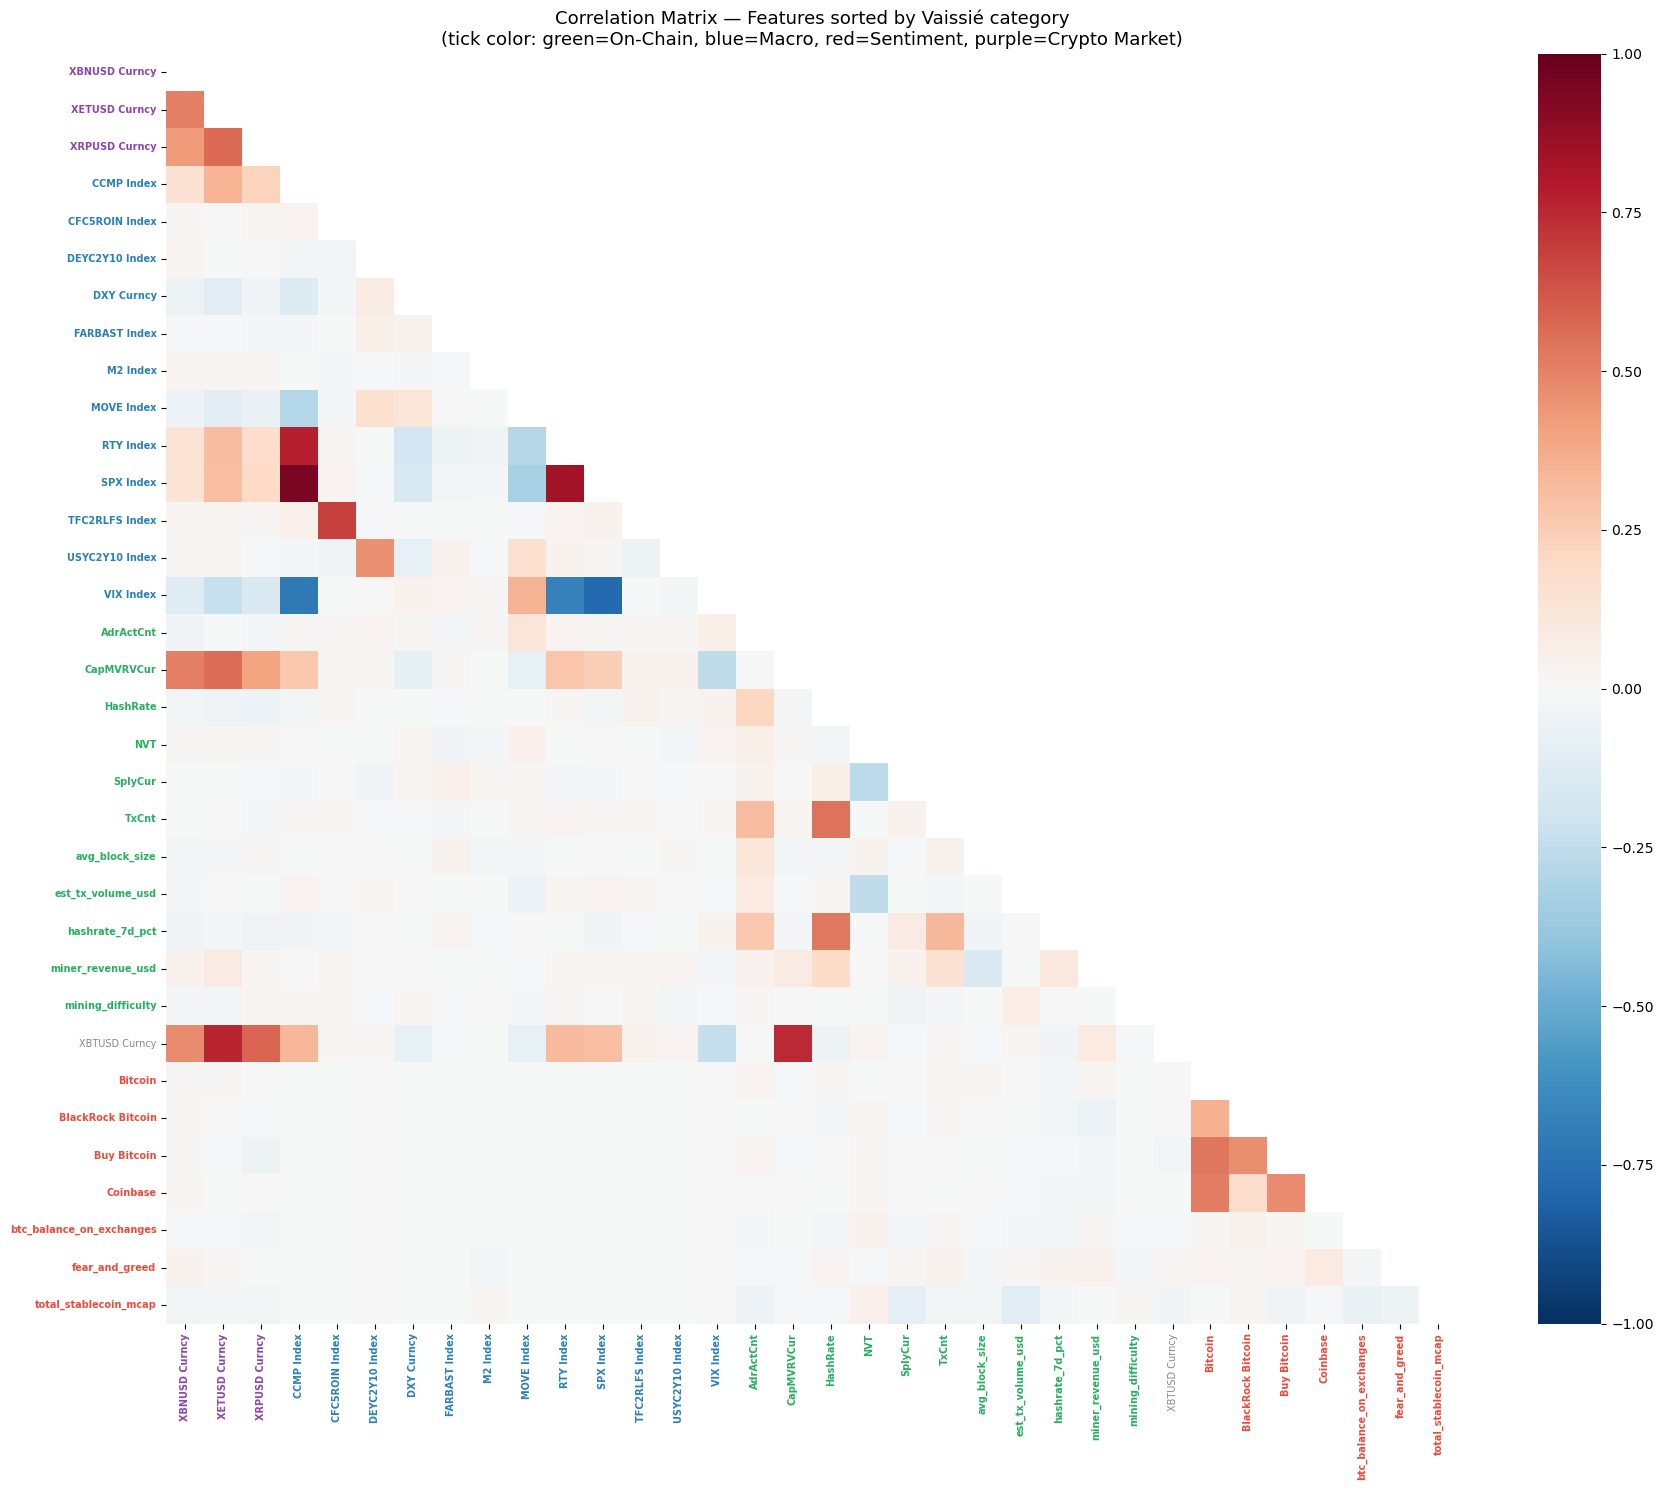


Top 15 correlations with XBTUSD Curncy (after stationarity transforms):
  XETUSD Curncy                   r=+0.760  (Crypto Market)
  CapMVRVCur                      r=+0.744  (On-Chain)
  XRPUSD Curncy                   r=+0.585  (Crypto Market)
  XBNUSD Curncy                   r=+0.470  (Crypto Market)
  CCMP Index                      r=+0.334  (Macro)
  RTY Index                       r=+0.320  (Macro)
  SPX Index                       r=+0.299  (Macro)
  VIX Index                       r=-0.236  (Macro)
  miner_revenue_usd               r=+0.090  (On-Chain)
  DXY Curncy                      r=-0.083  (Macro)
  MOVE Index                      r=-0.079  (Macro)
  HashRate                        r=-0.052  (On-Chain)
  TFC2RLFS Index                  r=+0.034  (Macro)
  total_stablecoin_mcap           r=-0.033  (Sentiment)
  hashrate_7d_pct                 r=-0.032  (On-Chain)


In [7]:
# ============================================================
# CORRELATION HEATMAP BY CATEGORY
# ============================================================
# This is the phenomenological observation: which features are
# statistically associated with BTC returns?
# Remember: correlation ≠ causation. A high correlation between
# X and BTC could be because X causes BTC, BTC causes X,
# or a confounder Z causes both.

corr = df_stationary.corr()

# Sort columns by category for visual grouping
sorted_cols = sorted(df_stationary.columns, key=lambda x: (get_category(x), x))
corr_sorted = corr.loc[sorted_cols, sorted_cols]

fig, ax = plt.subplots(figsize=(18, 15))
mask = np.triu(np.ones_like(corr_sorted, dtype=bool))
sns.heatmap(corr_sorted, mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, annot=False, ax=ax,
            xticklabels=True, yticklabels=True)

# Color tick labels by Vaissié category for readability
for label in ax.get_xticklabels():
    cat = get_category(label.get_text())
    label.set_color(CATEGORY_COLORS.get(cat, '#7f8c8d'))
    label.set_fontweight('bold' if cat != 'Other' else 'normal')
for label in ax.get_yticklabels():
    cat = get_category(label.get_text())
    label.set_color(CATEGORY_COLORS.get(cat, '#7f8c8d'))
    label.set_fontweight('bold' if cat != 'Other' else 'normal')

ax.set_title('Correlation Matrix — Features sorted by Vaissié category\n'
             '(tick color: green=On-Chain, blue=Macro, red=Sentiment, purple=Crypto Market)',
             fontsize=13)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

# Top correlations with BTC
if BTC_TICKER in corr.columns:
    btc_corr = corr[BTC_TICKER].drop(BTC_TICKER, errors='ignore')
    # Exclude BTC-derived variables
    btc_corr = btc_corr.drop([v for v in BTC_DERIVED if v in btc_corr.index], errors='ignore')
    btc_corr = btc_corr.sort_values(key=abs, ascending=False)
    
    print(f"\nTop 15 correlations with {BTC_TICKER} (after stationarity transforms):")
    for feat, val in btc_corr.head(15).items():
        print(f"  {feat:30s}  r={val:+.3f}  ({get_category(feat)})")

**Phenomenological step summary:** We observed statistical associations between BTC and features across all three pillars. The strongest correlations were found with Crypto Market features (ETH: r=+0.76, XRP: r=+0.59), On-Chain metrics (MVRV: r=+0.74), and Macro indices (Nasdaq: r=+0.33, VIX: r=-0.24). Sentiment features showed weaker linear correlations (stablecoin mcap: r=-0.03), which does not rule out causal effects — a weak correlation can mask a strong causal relationship if confounders are present. Per López de Prado, we now move to the theoretical step where we propose and test causal structures.

---
## Section 2 — Theoretical Step: Causal Discovery

> *"The second step is theoretical: we propose a falsifiable causal mechanism explaining the observed association. The mechanism must specify the causal path from X to Y through measurable intermediate variables."*  
> — López de Prado, "Causal Factor Investing" (2023)

We apply **4 complementary causal discovery methods**, each with different assumptions:

| Method | Type | Key Assumption | Strengths | Weaknesses |
|--------|------|----------------|-----------|------------|
| **PC Algorithm** | Constraint-based | Faithfulness + Causal Sufficiency | Handles high dimensions; orients edges via v-structures | Requires no latent confounders |
| **NOTEARS** | Score-based (continuous) | DAG = weighted adjacency matrix with tr(e^{W⊙W})−d=0 | Continuous optimization; produces edge weights | Assumes linear relationships |
| **PCMCI** | Temporal constraint-based | Momentary Conditional Independence (MCI) | Detects lagged causes; controls for autocorrelation | Requires choosing max lag |
| **Granger** | Predictive causality | Past of X improves forecast of Y | Simple, bidirectional test; lag detection | Only temporal precedence, not true causation |

A feature is considered a **consensus causal candidate** if detected by **2 or more methods**. This multi-method approach reduces false positives from any single method's assumptions.

In [8]:
# ============================================================
# HELPER: Prepare data for causal methods
# ============================================================

# Features that are bounded/ratio — must use first-difference, NOT pct_change.
# pct_change on a 0-100 index is meaningless (a move from 50 to 51 is not +2%).
BOUNDED_FEATURES = {
    'fear_and_greed', 'CapMVRVCur', 'NVT', 'NVT_Signal',
    'active_addr_ratio', 'btc_dominance_proxy',
    'VIX Index', 'MOVE Index',
    'USYC2Y10 Index', 'DEYC2Y10 Index',
    'CESIUSD Index', 'CESIJPY Index',
}

# Google Trends keywords are weekly 0-100 indices — also use first-diff
GOOGLE_TRENDS = {
    'Bitcoin', 'Coinbase', 'BlackRock Bitcoin', 'Bitcoin Halving',
    'Buy Bitcoin', 'FOMO', 'HODL', 'Bull Run', 'Bear Market',
    'Crypto', 'Bitcoin Mining', 'Recession', 'Inflation', 'Interest Rates',
}

def prepare_causal_data(pivot_df, tickers, target, resample='W', start_date='2015-01-01'):
    """
    Prepare data for causal discovery methods.
    
    CRITICAL DESIGN CHOICES:
    1. Truncate to COMMON date range (not dropna(axis=1) which kills late-starting features)
    2. Use first-diff for bounded/ratio features (fear_and_greed, VIX, yield curves, Google Trends)
    3. Use pct_change for price/volume features
    4. Forward-fill only (no bfill = no look-ahead bias)
    
    Args:
        pivot_df: raw price/level data (DatetimeIndex)
        tickers: list of feature names to include
        target: target variable name (BTC_TICKER)
        resample: frequency ('W' for weekly, 'D' for daily)
        start_date: earliest date to include
    
    Returns:
        DataFrame of stationary returns/diffs, ready for causal methods
    """
    tickers = list(dict.fromkeys(tickers))
    available = [c for c in tickers if c in pivot_df.columns]
    if target in pivot_df.columns and target not in available:
        available.append(target)
    available = list(dict.fromkeys(available))
    
    df = pivot_df[available].copy()
    df = df[df.index >= start_date]
    df = df.resample(resample).mean()
    
    # FIX: Instead of dropna(axis=1) which kills late-starting features,
    # truncate to the common date range where most features have data.
    # Require at least 30% of features to have non-NaN values for a row.
    first_valid = df.apply(lambda s: s.first_valid_index())
    common_start = first_valid.quantile(0.7)  # Allow 30% of features to start later
    df = df[df.index >= common_start]
    
    # Forward-fill gaps (no bfill = no look-ahead bias)
    df = df.ffill()
    
    # Drop features that STILL have >50% NaN after truncation + ffill
    na_frac = df.isna().mean()
    df = df.drop(columns=na_frac[na_frac > 0.5].index.tolist())
    df = df.dropna()
    
    # Apply appropriate transforms for stationarity
    df_transformed = pd.DataFrame(index=df.index)
    for col in df.columns:
        if col in BOUNDED_FEATURES or col in GOOGLE_TRENDS:
            # Bounded/ratio features: first difference
            df_transformed[col] = df[col].diff()
        else:
            # Price/volume features: percentage change
            df_transformed[col] = df[col].pct_change()
    
    # Clean up
    df_transformed = df_transformed.replace([np.inf, -np.inf], np.nan)
    df_transformed = df_transformed.iloc[1:]  # Drop first row (NaN from diff/pct_change)
    df_transformed = df_transformed.ffill().dropna()
    
    print(f"  Data prepared: {df_transformed.shape[0]} periods x {df_transformed.shape[1]} features")
    missing_from_requested = set(tickers) - set(df_transformed.columns) - BTC_DERIVED
    if missing_from_requested:
        print(f"  Features dropped (insufficient data): {sorted(missing_from_requested)}")
    
    return df_transformed

# Initialize results collector for cross-method comparison
# Structure: {feature_name: {method_name: result_type}}
method_results = {}

print("Helper ready.")

Helper ready.


### 2.1 — PC Algorithm (Peter-Clark)

**Reference:** Spirtes, Glymour & Scheines (2000), "Causation, Prediction, and Search"

**How it works:**
1. Start with a **fully connected** undirected graph (all features connected)
2. **Skeleton phase:** For each pair (X, Y), test if they are conditionally independent given subsets of other variables. If X ⊥ Y | Z for some conditioning set Z, remove the edge X—Y.
   - Uses Fisher's Z-test for conditional independence (assumes Gaussian data)
3. **Orientation phase:** Orient edges using **v-structures** (colliders): if X—Z—Y with no edge X—Y, then X→Z←Y.
4. Apply Meek's orientation rules to propagate further directions.

**Parameters:**
- `alpha=0.05`: significance level for independence tests (lower = fewer edges = sparser graph)
- `indep_test='fisherz'`: Fisher's Z-test for linear conditional independence

**Library:** `causal-learn` (CMU Causal Discovery team)

  Data prepared: 405 periods x 34 features
PC input: 405 weeks x 34 features
Features: ['HashRate', 'mining_difficulty', 'miner_revenue_usd', 'hashrate_7d_pct', 'AdrActCnt', 'TxCnt', 'est_tx_volume_usd', 'avg_block_size', 'CapMVRVCur', 'NVT', 'SplyCur', 'VIX Index', 'MOVE Index', 'DXY Curncy', 'SPX Index', 'CCMP Index', 'RTY Index', 'USYC2Y10 Index', 'DEYC2Y10 Index', 'M2 Index', 'FARBAST Index', 'TFC2RLFS Index', 'CFC5ROIN Index', 'fear_and_greed', 'total_stablecoin_mcap', 'btc_balance_on_exchanges', 'Bitcoin', 'Coinbase', 'BlackRock Bitcoin', 'Buy Bitcoin', 'XETUSD Curncy', 'XBNUSD Curncy', 'XRPUSD Curncy', 'XBTUSD Curncy']


  0%|          | 0/34 [00:00<?, ?it/s]


PC Algorithm Results for XBTUSD Curncy:
  Causes → BTC (4): ['miner_revenue_usd', 'CapMVRVCur', 'XETUSD Curncy', 'XBNUSD Curncy']
  BTC → Effects (0): []
  Bidirectional (0): []
  Unoriented (0): []


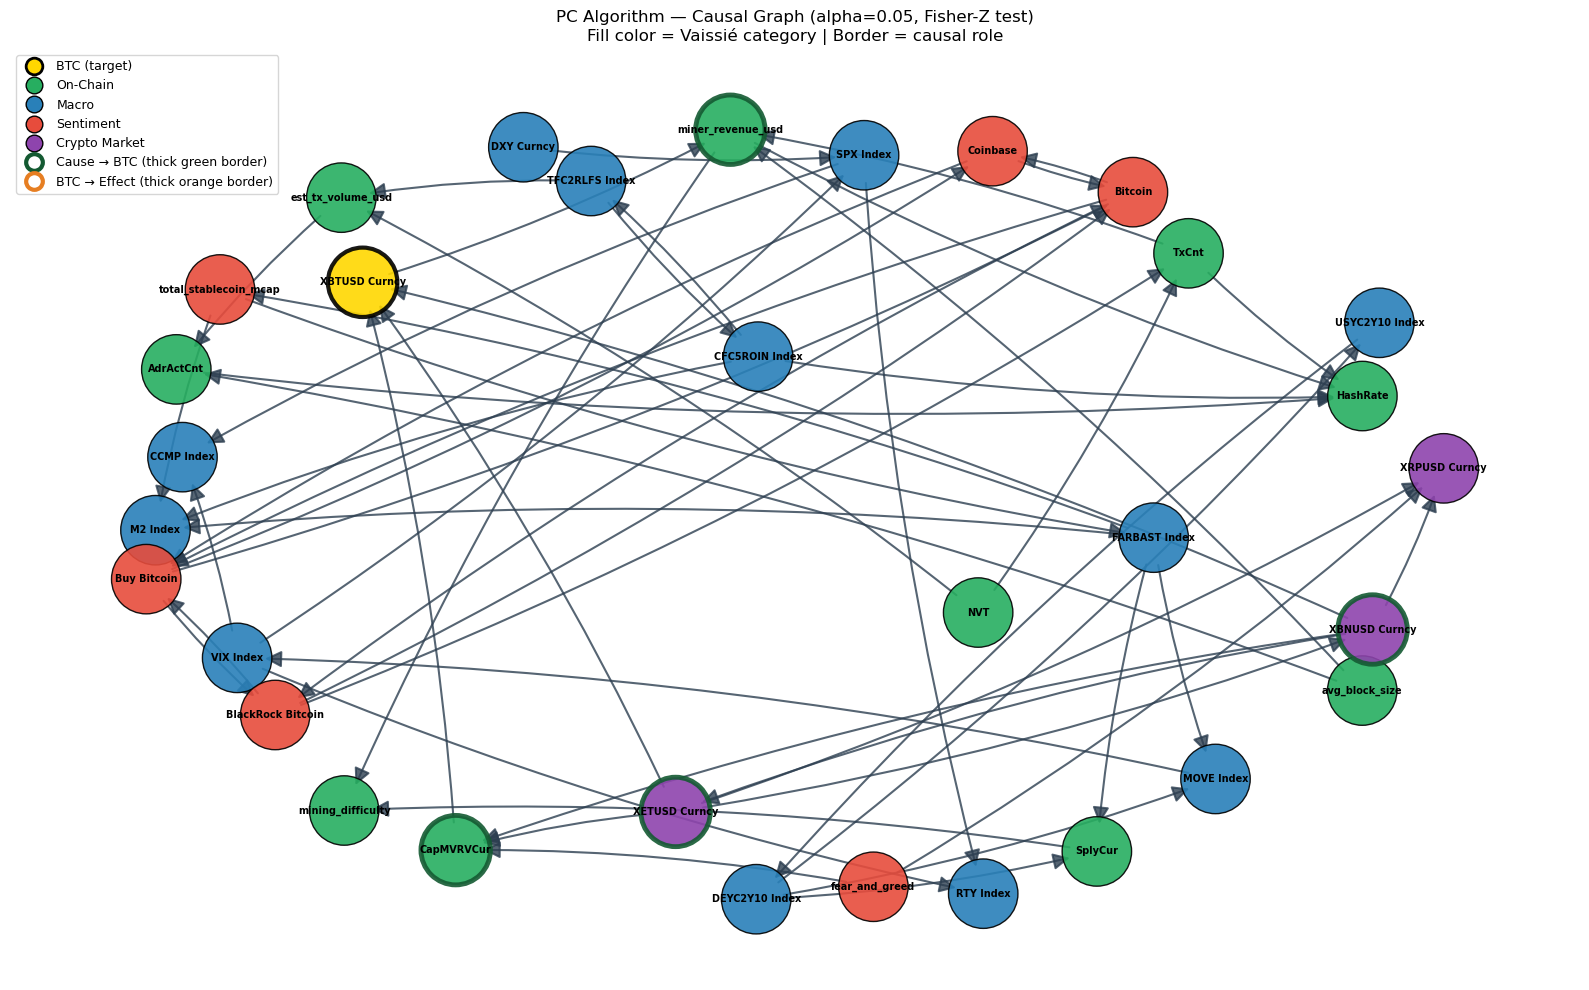

In [9]:
# ============================================================
# PC ALGORITHM
# ============================================================
from causallearn.search.ConstraintBased.PC import pc

# Prepare weekly returns data (weekly resampling reduces noise for PC)
df_pc = prepare_causal_data(pivot_df, available_tickers, BTC_TICKER, resample='W')

# Ensure BTC is not accidentally removed by dropna
if BTC_TICKER not in df_pc.columns:
    raise ValueError(f"{BTC_TICKER} was dropped during data preparation — check completeness.")

node_names = list(df_pc.columns)
btc_idx = node_names.index(BTC_TICKER)

print(f"PC input: {df_pc.shape[0]} weeks x {df_pc.shape[1]} features")
print(f"Features: {node_names}")

# Run PC algorithm
cg = pc(
    df_pc.values,
    alpha=0.05,           # Significance level for conditional independence tests
    indep_test='fisherz', # Fisher's Z-test (assumes linearity + Gaussianity)
    node_names=node_names
)

# ---- Analyze edges connected to BTC ----
# Edge types in causal-learn:
#   TAIL--ARROW: directed edge (tail→arrow)
#   ARROW--ARROW: bidirectional (latent confounder suspected)
#   TAIL--TAIL: undirected (direction unknown)
pc_causes = []     # X → BTC (feature causes BTC)
pc_effects = []    # BTC → X (BTC causes feature)
pc_bidirect = []   # X ↔ BTC (bidirectional / latent confounder)
pc_unoriented = [] # X — BTC (edge exists but direction unknown)

for i in range(len(node_names)):
    if i == btc_idx:
        continue
    # Skip BTC-derived variables
    if node_names[i] in BTC_DERIVED:
        continue
    
    node_i = cg.G.nodes[i]
    node_btc = cg.G.nodes[btc_idx]
    edge = cg.G.get_edge(node_i, node_btc)
    if edge is None:
        continue
    
    ep1 = str(edge.get_endpoint1())  # endpoint on node_i's side
    ep2 = str(edge.get_endpoint2())  # endpoint on BTC's side
    
    if ep1 == 'TAIL' and ep2 == 'ARROW':    # node_i → BTC
        pc_causes.append(node_names[i])
    elif ep1 == 'ARROW' and ep2 == 'TAIL':  # BTC → node_i
        pc_effects.append(node_names[i])
    elif ep1 == 'ARROW' and ep2 == 'ARROW': # node_i ↔ BTC (bidirectional)
        pc_bidirect.append(node_names[i])
    else:                                     # undirected
        pc_unoriented.append(node_names[i])

# Store results in cross-method tracker
for f in pc_causes:
    method_results.setdefault(f, {})['PC'] = 'cause'
for f in pc_effects:
    method_results.setdefault(f, {})['PC'] = 'effect'
for f in pc_bidirect:
    method_results.setdefault(f, {})['PC'] = 'bidirectional'
for f in pc_unoriented:
    method_results.setdefault(f, {})['PC'] = 'unoriented'

print(f"\nPC Algorithm Results for {BTC_TICKER}:")
print(f"  Causes → BTC ({len(pc_causes)}): {pc_causes}")
print(f"  BTC → Effects ({len(pc_effects)}): {pc_effects}")
print(f"  Bidirectional ({len(pc_bidirect)}): {pc_bidirect}")
print(f"  Unoriented ({len(pc_unoriented)}): {pc_unoriented}")

# ---- Visualization ----
def plot_pc_graph(cg, node_names, target, causes, effects):
    """Plot the PC algorithm causal graph with category-colored nodes.
    
    Node fill = Vaissié category color (On-Chain/Macro/Sentiment/Crypto Market).
    Border = role: thick dark green for causes, thick orange for effects, thin black otherwise.
    BTC (target) = gold fill.
    """
    G = nx.DiGraph()
    for i in range(len(node_names)):
        for j in range(len(node_names)):
            if cg.G.graph[i, j] == -1:  # -1 = arrow endpoint
                G.add_edge(node_names[i], node_names[j])
    
    # Node colors = category
    node_colors = []
    edge_colors = []  # border colors
    linewidths = []
    for n in G.nodes():
        if n == target:
            node_colors.append('gold')
            edge_colors.append('black')
            linewidths.append(3)
        else:
            node_colors.append(CATEGORY_COLORS.get(get_category(n), '#7f8c8d'))
            if n in causes:
                edge_colors.append('#145a32')  # dark green border = cause
                linewidths.append(3.5)
            elif n in effects:
                edge_colors.append('#e67e22')  # orange border = effect
                linewidths.append(3.5)
            else:
                edge_colors.append('black')
                linewidths.append(1)
    
    plt.figure(figsize=(16, 10))
    pos = nx.spring_layout(G, seed=42, k=2)
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2500,
                           edgecolors=edge_colors, linewidths=linewidths, alpha=0.9)
    nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=25, edge_color='#2c3e50',
                           width=1.5, alpha=0.8, arrowstyle='-|>',
                           connectionstyle='arc3,rad=0.05', min_source_margin=20, min_target_margin=20)
    nx.draw_networkx_labels(G, pos, font_size=7, font_weight='bold')
    
    # Legend: categories + roles
    legend = [
        plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='gold',
                   markersize=12, markeredgecolor='black', markeredgewidth=2, label='BTC (target)'),
    ]
    for cat, c in CATEGORY_COLORS.items():
        if cat != 'Other':
            legend.append(plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=c,
                          markersize=12, markeredgecolor='black', markeredgewidth=1, label=cat))
    # Role indicators
    legend.append(plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='white',
                  markersize=12, markeredgecolor='#145a32', markeredgewidth=3, label='Cause → BTC (thick green border)'))
    legend.append(plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='white',
                  markersize=12, markeredgecolor='#e67e22', markeredgewidth=3, label='BTC → Effect (thick orange border)'))
    plt.legend(handles=legend, loc='upper left', fontsize=9)
    plt.title('PC Algorithm — Causal Graph (alpha=0.05, Fisher-Z test)\n'
              'Fill color = Vaissié category | Border = causal role', fontsize=12)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_pc_graph(cg, node_names, BTC_TICKER, pc_causes, pc_effects)

### 2.2 — NOTEARS (Non-combinatorial Optimization)

**Reference:** Zheng et al. (2018), "DAGs with NO TEARS: Continuous Optimization for Structure Learning"

**How it works:**

Traditional DAG learning is NP-hard (combinatorial search over all possible graphs). NOTEARS reformulates it as a **continuous optimization problem**:

$$\min_W \frac{1}{2n} \|X - XW\|_F^2 + \lambda_1 \|W\|_1$$
$$\text{subject to } h(W) = \text{tr}(e^{W \circ W}) - d = 0$$

Where:
- $W$ is the weighted adjacency matrix ($W_{ij}$ = strength of edge $i \to j$)
- The first term is the least-squares data fit
- $\lambda_1 \|W\|_1$ is L1 regularization (promotes sparsity = fewer edges)
- $h(W) = 0$ is the **acyclicity constraint** (the key innovation) — the matrix exponential trace equals $d$ (number of variables) only when $W$ represents a DAG

The optimization uses augmented Lagrangian method with L-BFGS-B solver.

**Parameters:**
- `lambda1=0.1`: L1 penalty (higher = sparser graph)
- `w_threshold=0.3`: edges with |weight| < threshold are pruned

**Note:** Data must be standardized (zero mean, unit variance) for comparable edge weights.

In [10]:
# ============================================================
# NOTEARS IMPLEMENTATION
# ============================================================
from scipy.linalg import expm
from scipy.optimize import minimize

def notears_linear(X, lambda1=0.1, max_iter=100, h_tol=1e-8, rho_max=1e+16, w_threshold=0.3):
    """
    NOTEARS: continuous optimization for DAG structure learning.
    
    Args:
        X: (n, d) standardized data matrix
        lambda1: L1 regularization (sparsity control)
        max_iter: maximum augmented Lagrangian iterations
        h_tol: convergence tolerance for acyclicity constraint
        rho_max: maximum penalty parameter
        w_threshold: prune edges with |weight| below this
    
    Returns:
        W: (d, d) adjacency matrix where W[i,j] = weight of edge i→j
    """
    def _loss(W):
        """Least-squares loss: ||X - XW||^2 / (2n)"""
        R = X - X @ W
        return 0.5 / X.shape[0] * (R ** 2).sum()
    
    def _h(W):
        """Acyclicity constraint: tr(e^{W*W}) - d = 0 iff W is a DAG"""
        return np.trace(expm(W * W)) - W.shape[0]
    
    def _adj(w):
        """Reshape flat vector to (d,d) matrix with zero diagonal."""
        d = int(np.sqrt(len(w)))
        W = np.reshape(w, (d, d))
        return W - np.diag(np.diag(W))
    
    def _func(w, rho, alpha, h_val):
        """Augmented Lagrangian objective."""
        W = _adj(w)
        loss = _loss(W)
        h_new = _h(W)
        # Augmented Lagrangian: L + alpha*h + (rho/2)*h^2 + lambda1*|W|_1
        penalty = 0.5 * rho * h_new * h_new + alpha * h_new
        l1_pen = lambda1 * np.abs(W).sum()
        return loss + penalty + l1_pen
    
    n, d = X.shape
    w_est = np.zeros(d * d)
    rho, alpha, h = 1.0, 0.0, np.inf
    
    for it in range(max_iter):
        sol = minimize(_func, w_est, args=(rho, alpha, h), method='L-BFGS-B')
        w_est = sol.x
        W_est = _adj(w_est)
        h_new = _h(W_est)
        if h_new <= h_tol:
            print(f"  NOTEARS converged at iteration {it}")
            break
        alpha += rho * h_new
        if h_new > 0.25 * h:
            rho *= 10
            if rho > rho_max:
                print(f"  NOTEARS: rho_max reached at iteration {it}")
                break
        h = h_new
    
    # Prune weak edges
    W_est[np.abs(W_est) < w_threshold] = 0
    return W_est

# ---- Prepare data ----
df_notears = prepare_causal_data(pivot_df, available_tickers, BTC_TICKER, resample='W')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_notears)
notears_names = list(df_notears.columns)

print(f"NOTEARS input: {X_scaled.shape[0]} weeks x {X_scaled.shape[1]} features")

# ---- Run NOTEARS ----
W_est = notears_linear(X_scaled, lambda1=0.1, w_threshold=0.3)
n_edges = np.sum(W_est != 0)
print(f"Total edges detected: {n_edges}")

# ---- Analyze BTC connections ----
if BTC_TICKER in notears_names:
    btc_nt_idx = notears_names.index(BTC_TICKER)
    notears_causes = []   # Features with edges pointing INTO BTC
    notears_effects = []  # Features with edges FROM BTC
    
    # W[i,j] = weight of edge i→j in our formulation (X = XW means
    # column j is predicted by all rows, so W[i,j] = effect of i on j)
    for i in range(len(notears_names)):
        if notears_names[i] in BTC_DERIVED:
            continue  # Skip BTC-derived variables
        if W_est[i, btc_nt_idx] != 0 and i != btc_nt_idx:  # i → BTC
            notears_causes.append((notears_names[i], W_est[i, btc_nt_idx]))
    for j in range(len(notears_names)):
        if notears_names[j] in BTC_DERIVED:
            continue
        if W_est[btc_nt_idx, j] != 0 and j != btc_nt_idx:  # BTC → j
            notears_effects.append((notears_names[j], W_est[btc_nt_idx, j]))
    
    notears_causes.sort(key=lambda x: abs(x[1]), reverse=True)
    
    print(f"\nNOTEARS — Direct causes of {BTC_TICKER} ({len(notears_causes)}):")
    for feat, w in notears_causes:
        print(f"  {feat:30s}  weight={w:+.4f}  ({get_category(feat)})")
        method_results.setdefault(feat, {})['NOTEARS'] = 'cause'
    
    if notears_effects:
        print(f"\nNOTEARS — Effects of {BTC_TICKER} ({len(notears_effects)}):")
        for feat, w in notears_effects:
            print(f"  {feat:30s}  weight={w:+.4f}  ({get_category(feat)})")
            method_results.setdefault(feat, {})['NOTEARS'] = 'effect'
else:
    print(f"WARNING: {BTC_TICKER} not in NOTEARS dataset.")

  Data prepared: 405 periods x 34 features
NOTEARS input: 405 weeks x 34 features
  NOTEARS: rho_max reached at iteration 18
Total edges detected: 7

NOTEARS — Direct causes of XBTUSD Curncy (0):

NOTEARS — Effects of XBTUSD Curncy (2):
  CapMVRVCur                      weight=+0.4411  (On-Chain)
  XETUSD Curncy                   weight=+0.3253  (Crypto Market)


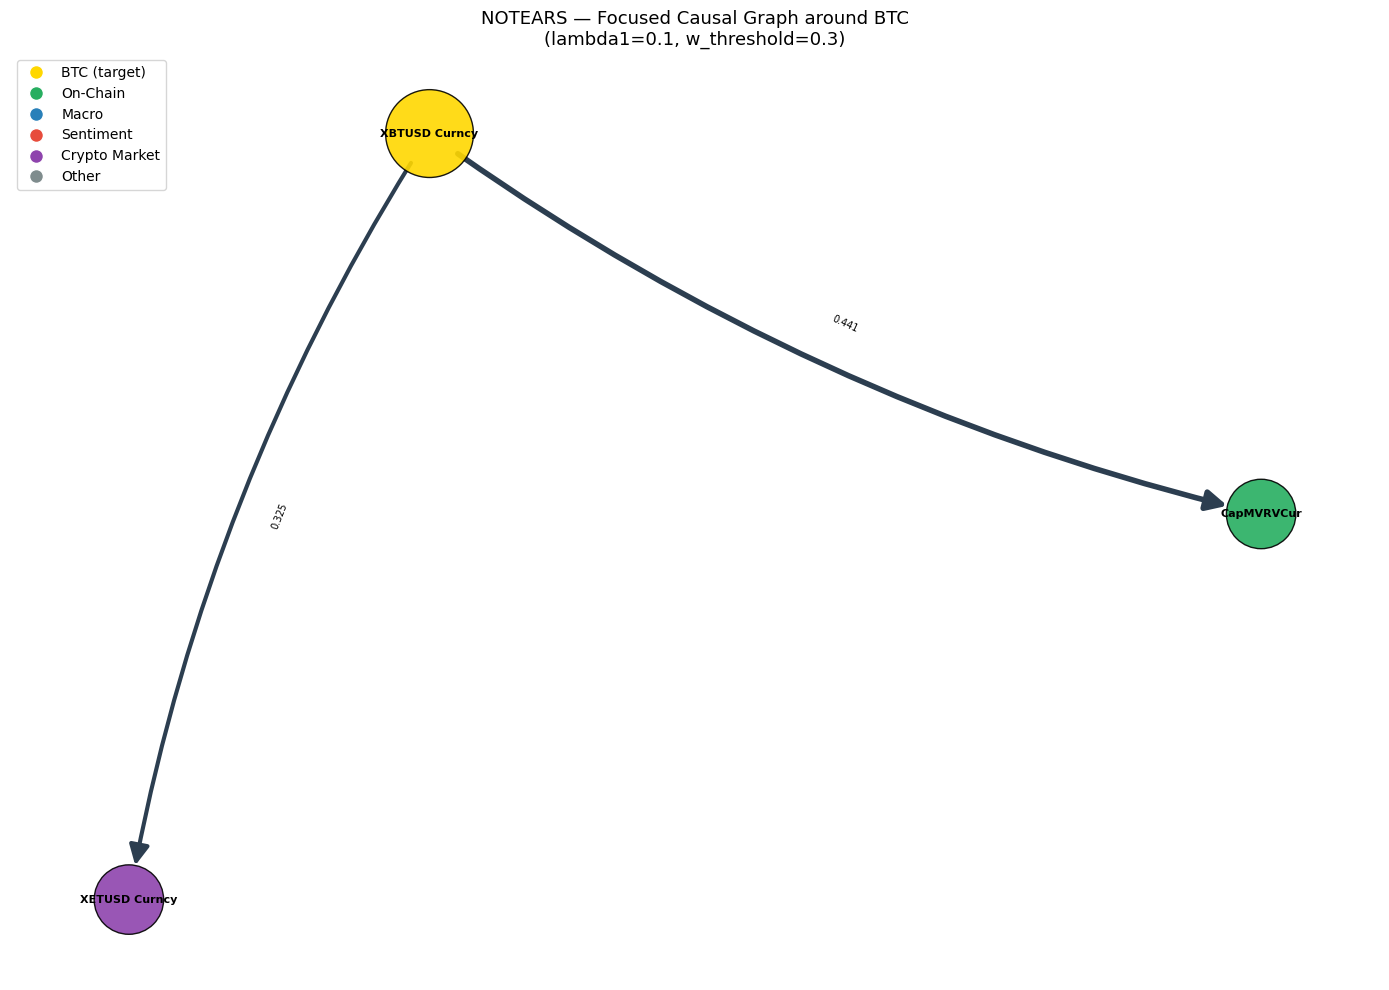

In [11]:
# NOTEARS — Focused graph visualization (only BTC and its direct connections)
if BTC_TICKER in notears_names:
    G_nt = nx.DiGraph()
    G_nt.add_node(BTC_TICKER)
    btc_nt_idx = notears_names.index(BTC_TICKER)
    
    # W[i,j] = i→j: causes of BTC are W[i, btc_idx] != 0
    for i in range(len(notears_names)):
        if notears_names[i] in BTC_DERIVED:
            continue
        if W_est[i, btc_nt_idx] != 0 and i != btc_nt_idx:
            G_nt.add_edge(notears_names[i], BTC_TICKER, weight=W_est[i, btc_nt_idx])
    # Effects of BTC are W[btc_idx, j] != 0
    for j in range(len(notears_names)):
        if notears_names[j] in BTC_DERIVED:
            continue
        if W_est[btc_nt_idx, j] != 0 and j != btc_nt_idx:
            G_nt.add_edge(BTC_TICKER, notears_names[j], weight=W_est[btc_nt_idx, j])
    
    if len(G_nt.nodes()) > 1:
        plt.figure(figsize=(14, 10))
        pos = nx.spring_layout(G_nt, k=2.5, seed=42)
        node_colors = ['gold' if n == BTC_TICKER else CATEGORY_COLORS.get(get_category(n), '#95a5a6') for n in G_nt.nodes()]
        node_sizes = [4000 if n == BTC_TICKER else 2500 for n in G_nt.nodes()]
        
        nx.draw_networkx_nodes(G_nt, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9, edgecolors='black')
        edges = list(G_nt.edges())
        weights = [abs(G_nt[u][v]['weight']) for u, v in edges]
        max_w = max(weights) if weights else 1
        nx.draw_networkx_edges(G_nt, pos, width=[max(1.5, w/max_w * 4) for w in weights],
                               edge_color='#2c3e50', arrows=True, arrowsize=30,
                               arrowstyle='-|>', connectionstyle='arc3,rad=0.1',
                               min_source_margin=25, min_target_margin=25)
        nx.draw_networkx_labels(G_nt, pos, font_size=8, font_weight='bold')
        edge_labels = {(u,v): f"{G_nt[u][v]['weight']:.3f}" for u,v in edges}
        nx.draw_networkx_edge_labels(G_nt, pos, edge_labels, font_size=7)
        
        legend = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=c, markersize=10, label=cat)
                  for cat, c in CATEGORY_COLORS.items()]
        legend.insert(0, plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='gold', markersize=10, label='BTC (target)'))
        plt.legend(handles=legend, loc='upper left')
        plt.title('NOTEARS — Focused Causal Graph around BTC\n'
                  '(lambda1=0.1, w_threshold=0.3)', fontsize=13)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print("No direct relationships detected. Try reducing lambda1 or w_threshold.")

### 2.3 — PCMCI (Temporal Causal Discovery)

**Reference:** Runge et al. (2019), "Detecting and quantifying causal associations in large nonlinear time series datasets"

**How it works:**

PCMCI combines two steps:
1. **PC-stable condition selection:** For each variable, identify a set of potential parents using the PC algorithm adapted for time series (testing X(t-τ) ⊥ Y(t) | conditioning set).
2. **MCI (Momentary Conditional Independence) test:** For each potential link X(t-τ) → Y(t), test:
   $$X(t-\tau) \perp\!\!\!\perp Y(t) \mid \text{Parents}(Y) \setminus \{X(t-\tau)\}, \text{Parents}(X)$$
   This controls for autocorrelation and indirect paths, reducing false positives.

**Key advantage over Granger:** PCMCI tests MCI which conditions on ALL other parents, not just the variable's own past. This means it can detect contemporaneous links (lag=0) and distinguish direct from indirect causes.

**Parameters:**
- `tau_min=0`: test contemporaneous effects (same week)
- `tau_max=4`: test up to 4-week lags (~1 month)
- `pc_alpha=0.05`: significance level for condition selection
- `cond_ind_test=ParCorr()`: partial correlation test (linear assumption)

**Library:** `tigramite` (Runge's official implementation)

In [12]:
# ============================================================
# PCMCI — Temporal Causal Discovery
# ============================================================
from tigramite import data_processing as tp_dp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr

# Use WEEKLY data for PCMCI — Google Trends features are weekly,
# and daily resampling of weekly data creates NaN explosion.
# tau_max=4 below means 4-week lags (~1 month), appropriate for weekly data.
df_pcmci = prepare_causal_data(pivot_df, available_tickers, BTC_TICKER, resample='W')
print(f"PCMCI input: {df_pcmci.shape[0]} weeks x {df_pcmci.shape[1]} features")

pcmci_names = list(df_pcmci.columns)
btc_pcmci_idx = pcmci_names.index(BTC_TICKER)
data_arr = df_pcmci.values.astype(float)

# Tigramite requires its own DataFrame wrapper
dataframe = tp_dp.DataFrame(
    data_arr,
    datatime=np.arange(len(data_arr)),
    var_names=pcmci_names
)

print("Running PCMCI (this may take a minute)...")
pcmci_obj = PCMCI(
    dataframe=dataframe,
    cond_ind_test=ParCorr(),  # Partial correlation (linear)
    verbosity=0               # Suppress verbose output
)

pcmci_results = pcmci_obj.run_pcmci(
    tau_min=0,     # Include contemporaneous effects (lag=0)
    tau_max=4,     # Test up to 4-week lags (weekly data)
    pc_alpha=0.05  # Significance for condition selection
)

# ---- Analyze results: extract significant links to BTC ----
p_matrix = pcmci_results['p_matrix']
val_matrix = pcmci_results['val_matrix']

pcmci_contemp = []  # Contemporaneous causes (lag=0)
pcmci_lagged = []   # Lagged causes (lag>0)

for i in range(len(pcmci_names)):
    if i == btc_pcmci_idx:
        continue
    if pcmci_names[i] in BTC_DERIVED:
        continue
    for lag in range(0, 5):
        p_val = p_matrix[i, btc_pcmci_idx, lag]
        coeff = val_matrix[i, btc_pcmci_idx, lag]
        if p_val < ALPHA:
            entry = (pcmci_names[i], lag, coeff, p_val)
            if lag == 0:
                pcmci_contemp.append(entry)
            else:
                pcmci_lagged.append(entry)

# Store in cross-method tracker
for var, lag, coeff, pval in pcmci_contemp + pcmci_lagged:
    method_results.setdefault(var, {})['PCMCI'] = f'cause(lag={lag})'

print(f"\nPCMCI Results for {BTC_TICKER}:")
print(f"\nContemporaneous causes (lag=0) — same-day associations:")
if pcmci_contemp:
    for var, lag, coeff, pval in sorted(pcmci_contemp, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {var:30s}  coeff={coeff:+.4f}  p={pval:.4f}  ({get_category(var)})")
else:
    print("  None detected.")

print(f"\nLagged causes — X(t-lag) → BTC(t):")
if pcmci_lagged:
    for var, lag, coeff, pval in sorted(pcmci_lagged, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {var:30s}  lag={lag}d  coeff={coeff:+.4f}  p={pval:.4f}  ({get_category(var)})")
else:
    print("  None detected.")

print(f"\nTotal: {len(pcmci_contemp)} contemporaneous + {len(pcmci_lagged)} lagged = {len(pcmci_contemp)+len(pcmci_lagged)} causal links")

  Data prepared: 405 periods x 34 features
PCMCI input: 405 weeks x 34 features
Running PCMCI (this may take a minute)...

PCMCI Results for XBTUSD Curncy:

Contemporaneous causes (lag=0) — same-day associations:
  CapMVRVCur                      coeff=+0.9183  p=0.0000  (On-Chain)
  XETUSD Curncy                   coeff=+0.7810  p=0.0000  (Crypto Market)
  fear_and_greed                  coeff=+0.7135  p=0.0000  (Sentiment)
  XBNUSD Curncy                   coeff=+0.7112  p=0.0000  (Crypto Market)
  miner_revenue_usd               coeff=+0.5765  p=0.0000  (On-Chain)
  XRPUSD Curncy                   coeff=+0.4741  p=0.0000  (Crypto Market)
  RTY Index                       coeff=+0.3450  p=0.0000  (Macro)
  CCMP Index                      coeff=+0.3110  p=0.0000  (Macro)
  SPX Index                       coeff=+0.3015  p=0.0000  (Macro)
  AdrActCnt                       coeff=+0.2870  p=0.0000  (On-Chain)
  VIX Index                       coeff=-0.2863  p=0.0000  (Macro)
  CFC5ROIN In

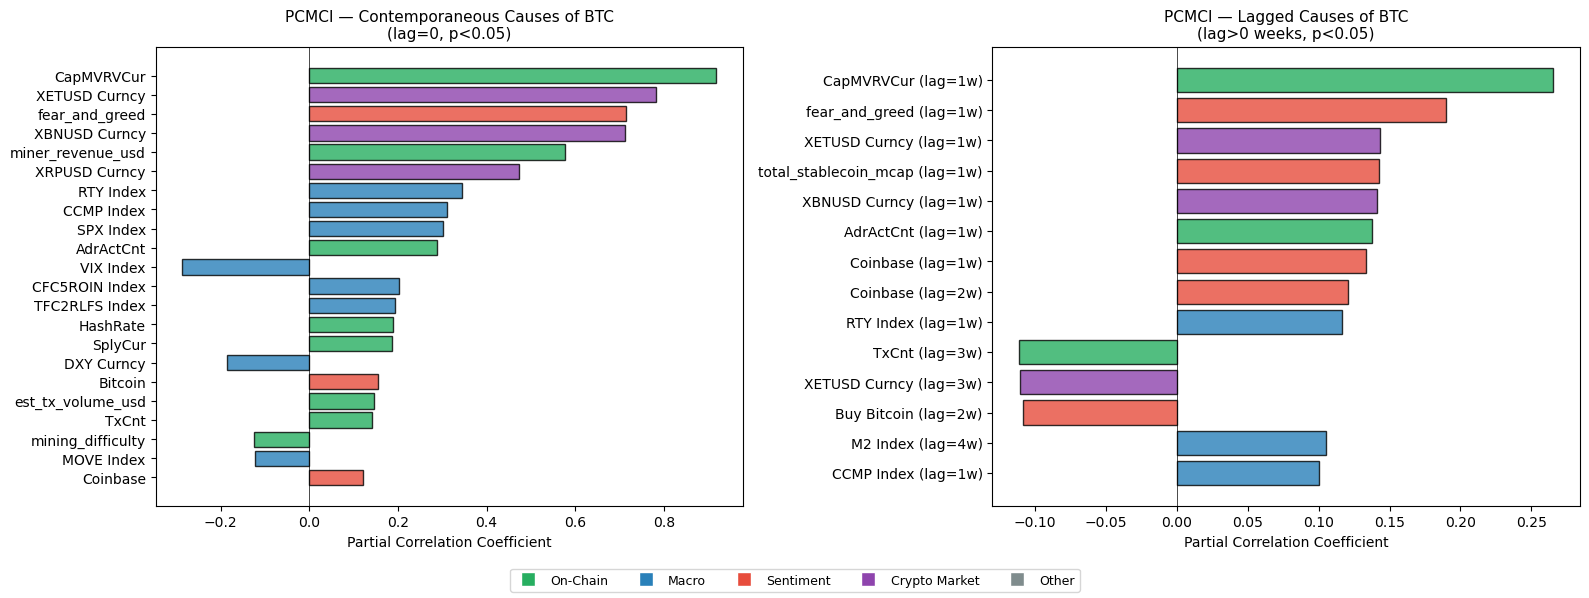

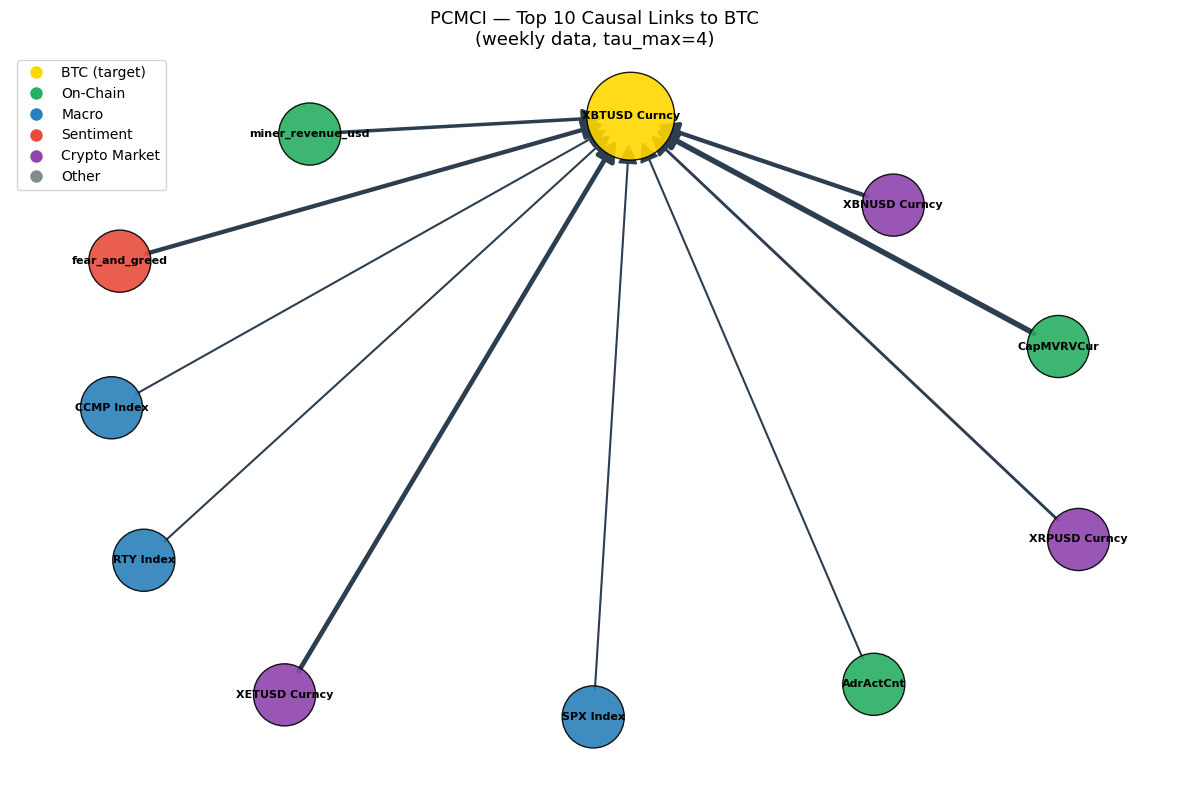

In [13]:
# PCMCI — Focused visualization (BTC connections only)
# The full tigramite plot is unreadable with 27+ variables.
# Instead, show only links involving BTC.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Bar chart of contemporaneous causes
if pcmci_contemp:
    contemp_df = pd.DataFrame(pcmci_contemp, columns=['Feature', 'Lag', 'Coeff', 'P-value'])
    contemp_df['Category'] = contemp_df['Feature'].apply(get_category)
    contemp_df = contemp_df.sort_values('Coeff', key=abs, ascending=True)
    colors = [CATEGORY_COLORS.get(c, '#95a5a6') for c in contemp_df['Category']]
    axes[0].barh(contemp_df['Feature'], contemp_df['Coeff'], color=colors, edgecolor='black', alpha=0.8)
    axes[0].set_xlabel('Partial Correlation Coefficient')
    axes[0].set_title(f'PCMCI — Contemporaneous Causes of BTC\n(lag=0, p<{ALPHA})', fontsize=11)
    axes[0].axvline(0, color='black', linewidth=0.5)
else:
    axes[0].text(0.5, 0.5, 'No contemporaneous\ncauses detected', ha='center', va='center')
    axes[0].set_title('PCMCI — Contemporaneous Causes')

# Right: Bar chart of lagged causes
if pcmci_lagged:
    lagged_df = pd.DataFrame(pcmci_lagged, columns=['Feature', 'Lag', 'Coeff', 'P-value'])
    lagged_df['Category'] = lagged_df['Feature'].apply(get_category)
    lagged_df['Label'] = lagged_df['Feature'] + ' (lag=' + lagged_df['Lag'].astype(str) + 'w)'
    lagged_df = lagged_df.sort_values('Coeff', key=abs, ascending=True)
    colors = [CATEGORY_COLORS.get(c, '#95a5a6') for c in lagged_df['Category']]
    axes[1].barh(lagged_df['Label'], lagged_df['Coeff'], color=colors, edgecolor='black', alpha=0.8)
    axes[1].set_xlabel('Partial Correlation Coefficient')
    axes[1].set_title(f'PCMCI — Lagged Causes of BTC\n(lag>0 weeks, p<{ALPHA})', fontsize=11)
    axes[1].axvline(0, color='black', linewidth=0.5)
else:
    axes[1].text(0.5, 0.5, 'No lagged\ncauses detected', ha='center', va='center')
    axes[1].set_title('PCMCI — Lagged Causes')

# Legend
legend_handles = [plt.Line2D([0],[0], marker='s', color='w', markerfacecolor=c, markersize=10, label=cat)
                  for cat, c in CATEGORY_COLORS.items()]
fig.legend(handles=legend_handles, loc='lower center', ncol=len(CATEGORY_COLORS), fontsize=9)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

# Also show a focused directed graph (top 10 links only for readability)
all_pcmci = pcmci_contemp + pcmci_lagged
if all_pcmci:
    top_links = sorted(all_pcmci, key=lambda x: abs(x[2]), reverse=True)[:10]
    G_pcmci = nx.DiGraph()
    G_pcmci.add_node(BTC_TICKER)
    for feat, lag, coeff, pval in top_links:
        label = f"{feat}\n(lag={lag}w)" if lag > 0 else feat
        G_pcmci.add_edge(label, BTC_TICKER, weight=abs(coeff))
    
    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G_pcmci, k=2.5, seed=42)
    node_colors = ['gold' if n == BTC_TICKER else 
                   CATEGORY_COLORS.get(get_category(n.split('\n')[0]), '#95a5a6') 
                   for n in G_pcmci.nodes()]
    node_sizes = [4000 if n == BTC_TICKER else 2000 for n in G_pcmci.nodes()]
    
    nx.draw_networkx_nodes(G_pcmci, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9, edgecolors='black')
    edges = list(G_pcmci.edges())
    weights = [G_pcmci[u][v]['weight'] for u, v in edges]
    max_w = max(weights) if weights else 1
    nx.draw_networkx_edges(G_pcmci, pos, width=[max(1.5, w/max_w*4) for w in weights],
                           edge_color='#2c3e50', arrows=True, arrowsize=30,
                           arrowstyle='-|>', min_source_margin=20, min_target_margin=20)
    nx.draw_networkx_labels(G_pcmci, pos, font_size=8, font_weight='bold')
    
    legend = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=c, markersize=10, label=cat)
              for cat, c in CATEGORY_COLORS.items()]
    legend.insert(0, plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='gold', markersize=10, label='BTC (target)'))
    plt.legend(handles=legend, loc='upper left')
    plt.title(f'PCMCI — Top 10 Causal Links to BTC\n(weekly data, tau_max=4)', fontsize=13)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

### 2.4 — Granger Causality (Bidirectional)

**Reference:** Granger (1969), "Investigating Causal Relations by Econometric Models and Cross-spectral Methods"

**How it works:**

Granger causality tests a specific form of temporal precedence: *"X Granger-causes Y if past values of X improve the prediction of Y beyond Y's own past."*

Formally, we compare two VAR models:
- **Restricted:** $Y_t = \sum_{k=1}^{p} \alpha_k Y_{t-k} + \epsilon_t$
- **Unrestricted:** $Y_t = \sum_{k=1}^{p} \alpha_k Y_{t-k} + \sum_{k=1}^{p} \beta_k X_{t-k} + \epsilon_t$

An F-test checks if the $\beta_k$ coefficients are jointly significant (SSR reduction).

**Bidirectional testing:** We test BOTH directions:
- Feature → BTC (does the feature predict BTC?)
- BTC → Feature (does BTC predict the feature?)

This allows us to classify each relationship as:
- **Cause:** Feature → BTC only
- **Reverse:** BTC → Feature only (feature reacts to price)
- **Bidirectional:** Both directions significant (feedback loop)
- **None:** Neither direction significant

**Important limitation:** Granger causality is NOT true causation — it only tests temporal precedence. A third variable could drive both. This is why we combine it with other methods.

**Adapted from:** `src/analysis/causality/determine_causal_arrows.py`

In [14]:
# ============================================================
# GRANGER CAUSALITY — Bidirectional testing
# ============================================================
GRANGER_MAXLAG = 7  # Test up to 7-day lags

def run_granger_test(df, cause_col, effect_col, maxlag=GRANGER_MAXLAG):
    """
    Run Granger causality F-test.
    Returns (min_p_value_across_lags, best_lag).
    
    Note: grangercausalitytests() expects columns in order [Y, X]
    where we test if X Granger-causes Y.
    """
    data = df[[effect_col, cause_col]].dropna()
    if len(data) < 100:  # Need sufficient observations
        return 1.0, 0
    try:
        result = grangercausalitytests(data, maxlag=maxlag, verbose=False)
        p_values = [result[i+1][0]['ssr_ftest'][1] for i in range(maxlag)]
        min_p = min(p_values)
        best_lag = p_values.index(min_p) + 1
        return min_p, best_lag
    except Exception:
        return 1.0, 0

# Use the STATIONARY dataset (Granger requires stationarity)
granger_features = [c for c in df_stationary.columns 
                    if c != BTC_TICKER and c not in BTC_DERIVED]

print(f"Running bidirectional Granger tests on {len(granger_features)} features...")
print(f"Parameters: maxlag={GRANGER_MAXLAG} days, alpha={ALPHA}")
print(f"Data: {len(df_stationary)} daily observations (after stationarity transforms)\n")

granger_results = []

for feat in granger_features:
    # Forward test: does feature Granger-cause BTC?
    p_fwd, lag_fwd = run_granger_test(df_stationary, feat, BTC_TICKER)
    # Reverse test: does BTC Granger-cause feature?
    p_rev, lag_rev = run_granger_test(df_stationary, BTC_TICKER, feat)
    
    is_fwd = p_fwd < ALPHA
    is_rev = p_rev < ALPHA
    
    if is_fwd and not is_rev:
        direction = 'cause'
        method_results.setdefault(feat, {})['Granger'] = f'cause(lag={lag_fwd})'
    elif is_rev and not is_fwd:
        direction = 'reverse'
        method_results.setdefault(feat, {})['Granger'] = 'reverse'
    elif is_fwd and is_rev:
        direction = 'bidirectional'
        method_results.setdefault(feat, {})['Granger'] = 'bidirectional'
    else:
        direction = 'none'
    
    granger_results.append({
        'Feature': feat,
        'Category': get_category(feat),
        'p_fwd': p_fwd,
        'lag_fwd': lag_fwd,
        'p_rev': p_rev,
        'lag_rev': lag_rev,
        'Direction': direction,
    })

granger_df = pd.DataFrame(granger_results).sort_values('p_fwd')

# Print organized results
for dir_type in ['cause', 'bidirectional', 'reverse', 'none']:
    subset = granger_df[granger_df['Direction'] == dir_type]
    if len(subset) > 0:
        labels = {
            'cause': 'CAUSES (Feature → BTC)',
            'reverse': 'REVERSE (BTC → Feature)',
            'bidirectional': 'BIDIRECTIONAL (feedback loop)',
            'none': 'NO GRANGER LINK'
        }
        print(f"\n{labels[dir_type]} ({len(subset)}):")
        for _, row in subset.iterrows():
            if dir_type == 'cause':
                print(f"  {row['Feature']:30s}  p={row['p_fwd']:.4f}  best_lag={row['lag_fwd']}d  ({row['Category']})")
            elif dir_type == 'reverse':
                print(f"  {row['Feature']:30s}  p={row['p_rev']:.4f}  best_lag={row['lag_rev']}d  ({row['Category']})")
            elif dir_type == 'bidirectional':
                print(f"  {row['Feature']:30s}  p_fwd={row['p_fwd']:.4f}  p_rev={row['p_rev']:.4f}  ({row['Category']})")
            else:
                print(f"  {row['Feature']:30s}  ({row['Category']})")

Running bidirectional Granger tests on 33 features...
Parameters: maxlag=7 days, alpha=0.05
Data: 2837 daily observations (after stationarity transforms)


CAUSES (Feature → BTC) (7):
  CapMVRVCur                      p=0.0000  best_lag=1d  (On-Chain)
  mining_difficulty               p=0.0000  best_lag=5d  (On-Chain)
  XRPUSD Curncy                   p=0.0001  best_lag=1d  (Crypto Market)
  Coinbase                        p=0.0013  best_lag=4d  (Sentiment)
  XBNUSD Curncy                   p=0.0022  best_lag=7d  (Crypto Market)
  Bitcoin                         p=0.0401  best_lag=4d  (Sentiment)
  BlackRock Bitcoin               p=0.0498  best_lag=5d  (Sentiment)

BIDIRECTIONAL (feedback loop) (4):
  XETUSD Curncy                   p_fwd=0.0000  p_rev=0.0001  (Crypto Market)
  total_stablecoin_mcap           p_fwd=0.0001  p_rev=0.0001  (Sentiment)
  miner_revenue_usd               p_fwd=0.0287  p_rev=0.0000  (On-Chain)
  est_tx_volume_usd               p_fwd=0.0408  p_rev=0.0000  (On-

### 2.5 — Cross-Method Comparison

We now aggregate results from all 4 causal discovery methods into a single comparison table.

**Consensus rule:** A feature is a **consensus causal candidate** if it is detected as causal (cause, bidirectional, or unoriented link) by **2 or more** of the 4 methods. This multi-method approach is more robust than any single method because:
- PC may miss non-linear effects but handles high dimensions
- NOTEARS captures non-zero weighted effects but assumes linearity
- PCMCI detects lagged effects but requires choosing max lag
- Granger tests temporal precedence but not true causation

Features passing this consensus filter proceed to the falsification step (DoWhy).

In [15]:
# ============================================================
# CROSS-METHOD COMPARISON TABLE
# ============================================================
all_features = sorted(set(method_results.keys()) - BTC_DERIVED)
methods = ['PC', 'NOTEARS', 'PCMCI', 'Granger']

comparison_rows = []
for feat in all_features:
    row = {
        'Feature': feat,
        'Category': get_category(feat),
    }
    causal_count = 0
    for m in methods:
        result = method_results[feat].get(m, '')
        row[m] = result
        # Count as causal if the result indicates cause/bidirectional/unoriented
        # (anything except 'effect', 'reverse', 'none', or empty)
        if result and result not in ('effect', 'reverse', 'none', ''):
            causal_count += 1
    row['Causal_Count'] = causal_count
    row['Consensus'] = 'CAUSAL' if causal_count >= 2 else ''
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).sort_values('Causal_Count', ascending=False)

print("Cross-Method Comparison Table")
print("(Consensus = detected as causal by 2+ methods)")
print("=" * 110)
display_cols = ['Feature', 'Category'] + methods + ['Causal_Count', 'Consensus']
print(comparison_df[display_cols].to_string(index=False))

consensus_features = comparison_df[comparison_df['Consensus'] == 'CAUSAL']['Feature'].tolist()
print(f"\nConsensus causal candidates ({len(consensus_features)}): {consensus_features}")

# Breakdown by Vaissié category
print(f"\nBy Vaissié category:")
for cat in ['On-Chain', 'Macro', 'Sentiment', 'Crypto Market']:
    cat_feats = [f for f in consensus_features if get_category(f) == cat]
    if cat_feats:
        print(f"  {cat}: {cat_feats}")
uncategorized = [f for f in consensus_features if get_category(f) == 'Other']
if uncategorized:
    print(f"  Uncategorized: {uncategorized}")

Cross-Method Comparison Table
(Consensus = detected as causal by 2+ methods)
              Feature      Category    PC NOTEARS        PCMCI       Granger  Causal_Count Consensus
    miner_revenue_usd      On-Chain cause         cause(lag=0) bidirectional             3    CAUSAL
           CapMVRVCur      On-Chain cause  effect cause(lag=1)  cause(lag=1)             3    CAUSAL
        XETUSD Curncy Crypto Market cause  effect cause(lag=3) bidirectional             3    CAUSAL
        XBNUSD Curncy Crypto Market cause         cause(lag=1)  cause(lag=7)             3    CAUSAL
total_stablecoin_mcap     Sentiment               cause(lag=1) bidirectional             2    CAUSAL
    mining_difficulty      On-Chain               cause(lag=0)  cause(lag=5)             2    CAUSAL
    est_tx_volume_usd      On-Chain               cause(lag=0) bidirectional             2    CAUSAL
             Coinbase     Sentiment               cause(lag=2)  cause(lag=4)             2    CAUSAL
        XRPUSD

---
## Section 3 — Falsification Step: DoWhy Interventions

> *"The third step is falsification: we design experiments to test each component of the proposed mechanism. We use interventional studies or simulated interventions to verify that P(Y|do[X=x]) > P[Y], meaning X genuinely causes Y."*  
> — López de Prado, "Causal Factor Investing" (2023)

### DoWhy Framework

**Library:** Microsoft DoWhy (Sharma & Kiciman, 2020)

DoWhy implements the **4-step causal inference pipeline**:
1. **Model:** Define a causal graph (DAG) specifying treatment, outcome, and confounders
2. **Identify:** Find the causal estimand using the backdoor criterion
3. **Estimate:** Compute the Average Treatment Effect (ATE) using linear regression
4. **Refute:** Run robustness checks to validate the estimate

### Backdoor Criterion

For treatment T and outcome Y with confounders Z, the **backdoor adjustment** computes:

$$P(Y|do(T=t)) = \sum_z P(Y|T=t, Z=z) \cdot P(Z=z)$$

This blocks all non-causal ("backdoor") paths through confounders while keeping the direct causal path T→Y open.

### Refutation Tests

A causal claim **survives falsification** only if it passes these robustness tests:

| Test | What it does | Pass criterion |
|------|-------------|----------------|
| **Placebo treatment** | Permute T randomly → ATE should vanish | |placebo_ATE| < 0.5 × |original_ATE| |
| **Random common cause** | Add a random confounder → ATE should be stable | |new_ATE - ATE| < 0.2 × |ATE| |
| **Data subset** | Use 80% of data → ATE should be stable | |subset_ATE - ATE| < 0.3 × |ATE| |

### Graph Format

We use **GML format** for the causal graph (compatible with newer networkx versions, as discovered in BTC_V3.ipynb). Each confounder points to both the treatment and the outcome.

In [16]:
# ============================================================
# DoWhy ATE + REFUTATION TESTS
# Adapted from BTC_V3.ipynb (GML graph format)
# ============================================================
from dowhy import CausalModel

def run_dowhy_pipeline(pivot_df, treatments, confounders, horizon=7):
    """
    Run DoWhy ATE estimation + refutation for consensus causal features.
    
    The causal graph structure:
        Confounder_i → Treatment
        Confounder_i → target (BTC return)
        Treatment → target
    
    This assumes confounders affect both the treatment and outcome
    (standard backdoor structure).
    
    Args:
        pivot_df: raw price data (transforms applied internally)
        treatments: list of causal candidate feature names
        confounders: list of confounder feature names
        horizon: target horizon in days (7 or 30)
    
    Returns:
        DataFrame with ATE estimates and refutation results
    """
    df = pivot_df.copy()
    df.index = pd.to_datetime(df.index)
    
    if BTC_TICKER not in df.columns:
        raise ValueError(f"{BTC_TICKER} not found")
    
    # Target: cumulative log-return over next HORIZON days
    # log-return = ln(P_t / P_{t-1}), cumulative = rolling sum
    df['BTC_logret'] = np.log(df[BTC_TICKER]).diff()
    df['target'] = df['BTC_logret'].rolling(horizon).sum().shift(-horizon)
    df = df.dropna(subset=['BTC_logret', 'target'])
    # Only forward-fill — bfill would introduce look-ahead bias
    df = df.ffill()
    
    # Filter to available columns
    treatments = [t for t in treatments if t in df.columns and t not in BTC_DERIVED]
    confounders = [c for c in confounders if c in df.columns 
                   and c not in treatments and c not in BTC_DERIVED
                   and c != 'target']
    
    if not treatments:
        print("No treatments available in data!")
        return pd.DataFrame()
    
    # Apply stationarity transforms to treatment/confounder features
    # (DoWhy on raw non-stationary prices gives spurious regression)
    causal_df = df[['target'] + treatments + confounders].copy()
    for col in treatments + confounders:
        if col in causal_df.columns:
            causal_df[col] = pd.to_numeric(causal_df[col], errors='coerce')
            if col in BOUNDED_FEATURES or col in GOOGLE_TRENDS:
                causal_df[col] = causal_df[col].diff()
            else:
                causal_df[col] = causal_df[col].pct_change()
    causal_df = causal_df.replace([np.inf, -np.inf], np.nan)
    causal_df = causal_df.ffill().dropna()
    
    print(f"\nHorizon: {horizon} days | Sample: {len(causal_df)} obs | "
          f"Treatments: {len(treatments)} | Confounders: {len(confounders)}")
    
    results = []
    for T in treatments:
        # Build GML graph (DoWhy-compatible format)
        gml = 'graph [\n  directed 1\n'
        gml += f'  node [ id "{T}" label "{T}" ]\n'
        gml += f'  node [ id "target" label "target" ]\n'
        for c in confounders:
            gml += f'  node [ id "{c}" label "{c}" ]\n'
        # Confounder edges: confounder → treatment AND confounder → outcome
        for c in confounders:
            gml += f'  edge [ source "{c}" target "{T}" ]\n'
            gml += f'  edge [ source "{c}" target "target" ]\n'
        # Treatment edge: treatment → outcome
        gml += f'  edge [ source "{T}" target "target" ]\n'
        gml += ']\n'
        
        try:
            model = CausalModel(data=causal_df, treatment=T, outcome='target', graph=gml)
            estimand = model.identify_effect(proceed_when_unidentifiable=True)
            estimate = model.estimate_effect(estimand, method_name='backdoor.linear_regression')
            ate = float(estimate.value)
        except Exception as e:
            print(f"  {T}: estimation failed — {e}")
            continue
        
        # ---- Refutation tests ----
        placebo_ok, rcc_ok, subset_ok = False, False, False
        
        # 1. Placebo: permute treatment → ATE should vanish
        try:
            ref = model.refute_estimate(estimand, estimate,
                                        method_name='placebo_treatment_refuter',
                                        placebo_type='permute')
            placebo_new = getattr(ref, 'new_effect', None)
            placebo_ok = placebo_new is not None and abs(placebo_new) < abs(ate) * 0.5
        except Exception:
            placebo_new = None
        
        # 2. Random common cause: add noise confounder → ATE should be stable
        try:
            ref = model.refute_estimate(estimand, estimate,
                                        method_name='random_common_cause')
            rcc_new = getattr(ref, 'new_effect', None)
            rcc_ok = rcc_new is not None and abs(rcc_new - ate) < abs(ate) * 0.2
        except Exception:
            rcc_new = None
        
        # 3. Data subset: use 80% → ATE should be stable
        try:
            ref = model.refute_estimate(estimand, estimate,
                                        method_name='data_subset_refuter',
                                        subset_fraction=0.8)
            subset_new = getattr(ref, 'new_effect', None)
            subset_ok = subset_new is not None and abs(subset_new - ate) < abs(ate) * 0.3
        except Exception:
            subset_new = None
        
        passes = sum([placebo_ok, rcc_ok, subset_ok])
        
        results.append({
            'Feature': T,
            'Category': get_category(T),
            'Horizon': horizon,
            'ATE': ate,
            'Placebo': 'PASS' if placebo_ok else 'FAIL',
            'RandomCC': 'PASS' if rcc_ok else 'FAIL',
            'Subset': 'PASS' if subset_ok else 'FAIL',
            'Refutations_Passed': f"{passes}/3",
            'Survives': passes >= 2,
        })
        
        status = 'SURVIVES' if passes >= 2 else 'REFUTED'
        print(f"  {T:30s}  ATE={ate:+.6f}  "
              f"Placebo={'P' if placebo_ok else 'F'} "
              f"RCC={'P' if rcc_ok else 'F'} "
              f"Subset={'P' if subset_ok else 'F'}  "
              f"[{status}]")
    
    return pd.DataFrame(results)

# ---- Define confounders ----
# These are macro variables that plausibly affect both the treatment
# features AND BTC returns (backdoor paths).
all_confounders = [
    'SPX Index', 'CCMP Index', 'RTY Index', 'DXY Curncy',
    'M2 Index', 'ECMAM2 Index', 'EURUSD Curncy', 'JPYUSD Curncy',
]

print("=" * 70)
print("DoWhy CAUSAL EFFECT ESTIMATION + REFUTATION")
print("=" * 70)

# Fallback if no consensus features were found
if not consensus_features:
    print("\nNo consensus features (2+ methods). Falling back to features with 1+ method.")
    consensus_features = comparison_df[comparison_df['Causal_Count'] >= 1]['Feature'].tolist()

# Run for two horizons (per Vaissié: causal drivers change with time scale)
# Horizon 7d: short-term (sentiment-driven?)
# Horizon 30d: medium-term (on-chain/macro-driven?)
dowhy_7d = run_dowhy_pipeline(pivot_df, consensus_features, all_confounders, horizon=7)
dowhy_30d = run_dowhy_pipeline(pivot_df, consensus_features, all_confounders, horizon=30)

DoWhy CAUSAL EFFECT ESTIMATION + REFUTATION

Horizon: 7 days | Sample: 2097 obs | Treatments: 10 | Confounders: 8
  miner_revenue_usd               ATE=+0.003789  Placebo=P RCC=P Subset=P  [SURVIVES]
  CapMVRVCur                      ATE=+0.067737  Placebo=P RCC=P Subset=P  [SURVIVES]
  XETUSD Curncy                   ATE=-0.024109  Placebo=P RCC=P Subset=P  [SURVIVES]
  XBNUSD Curncy                   ATE=-0.025369  Placebo=P RCC=P Subset=P  [SURVIVES]
  total_stablecoin_mcap           ATE=+0.150467  Placebo=P RCC=P Subset=P  [SURVIVES]
  mining_difficulty               ATE=-0.069363  Placebo=P RCC=P Subset=P  [SURVIVES]
  est_tx_volume_usd               ATE=+0.000760  Placebo=F RCC=P Subset=P  [SURVIVES]
  Coinbase                        ATE=+0.011180  Placebo=P RCC=P Subset=P  [SURVIVES]
  XRPUSD Curncy                   ATE=-0.054711  Placebo=P RCC=P Subset=P  [SURVIVES]
  Bitcoin                         ATE=+0.000471  Placebo=P RCC=P Subset=P  [SURVIVES]

Horizon: 30 days | Sample

In [17]:
# ============================================================
# DoWhy RESULTS TABLE
# ============================================================
print("DoWhy Results — 7-day horizon:")
if len(dowhy_7d) > 0:
    print(dowhy_7d.to_string(index=False))
else:
    print("  No results.")

print("\nDoWhy Results — 30-day horizon:")
if len(dowhy_30d) > 0:
    print(dowhy_30d.to_string(index=False))
else:
    print("  No results.")

# Combine results from both horizons
dowhy_all = pd.concat([dowhy_7d, dowhy_30d], ignore_index=True)
survived = dowhy_all[dowhy_all['Survives']]
print(f"\nFeatures surviving DoWhy refutation: {survived['Feature'].unique().tolist()}")

DoWhy Results — 7-day horizon:
              Feature      Category  Horizon       ATE Placebo RandomCC Subset Refutations_Passed  Survives
    miner_revenue_usd      On-Chain        7  0.003789    PASS     PASS   PASS                3/3      True
           CapMVRVCur      On-Chain        7  0.067737    PASS     PASS   PASS                3/3      True
        XETUSD Curncy Crypto Market        7 -0.024109    PASS     PASS   PASS                3/3      True
        XBNUSD Curncy Crypto Market        7 -0.025369    PASS     PASS   PASS                3/3      True
total_stablecoin_mcap     Sentiment        7  0.150467    PASS     PASS   PASS                3/3      True
    mining_difficulty      On-Chain        7 -0.069363    PASS     PASS   PASS                3/3      True
    est_tx_volume_usd      On-Chain        7  0.000760    FAIL     PASS   PASS                2/3      True
             Coinbase     Sentiment        7  0.011180    PASS     PASS   PASS                3/3      Tr

---
## Section 4 — Conclusion: Final Consensus Causal Graph

A feature is considered a **validated causal driver** of Bitcoin if:
1. It was detected by **2+ causal discovery methods** (Section 2)
2. It **survived DoWhy refutation** (at least 2/3 tests passed) (Section 3)

Features with very strong discovery consensus (3+ methods) are also included even if DoWhy was inconclusive, since the convergence of multiple independent methods is itself strong evidence.

Final validated causal drivers of Bitcoin (10):
  Bitcoin                         (Sentiment      )  2 methods  [survived]
  CapMVRVCur                      (On-Chain       )  3 methods  [survived]
  Coinbase                        (Sentiment      )  2 methods  [survived]
  XBNUSD Curncy                   (Crypto Market  )  3 methods  [survived]
  XETUSD Curncy                   (Crypto Market  )  3 methods  [survived]
  XRPUSD Curncy                   (Crypto Market  )  2 methods  [survived]
  est_tx_volume_usd               (On-Chain       )  2 methods  [survived]
  miner_revenue_usd               (On-Chain       )  3 methods  [survived]
  mining_difficulty               (On-Chain       )  2 methods  [survived]
  total_stablecoin_mcap           (Sentiment      )  2 methods  [survived]


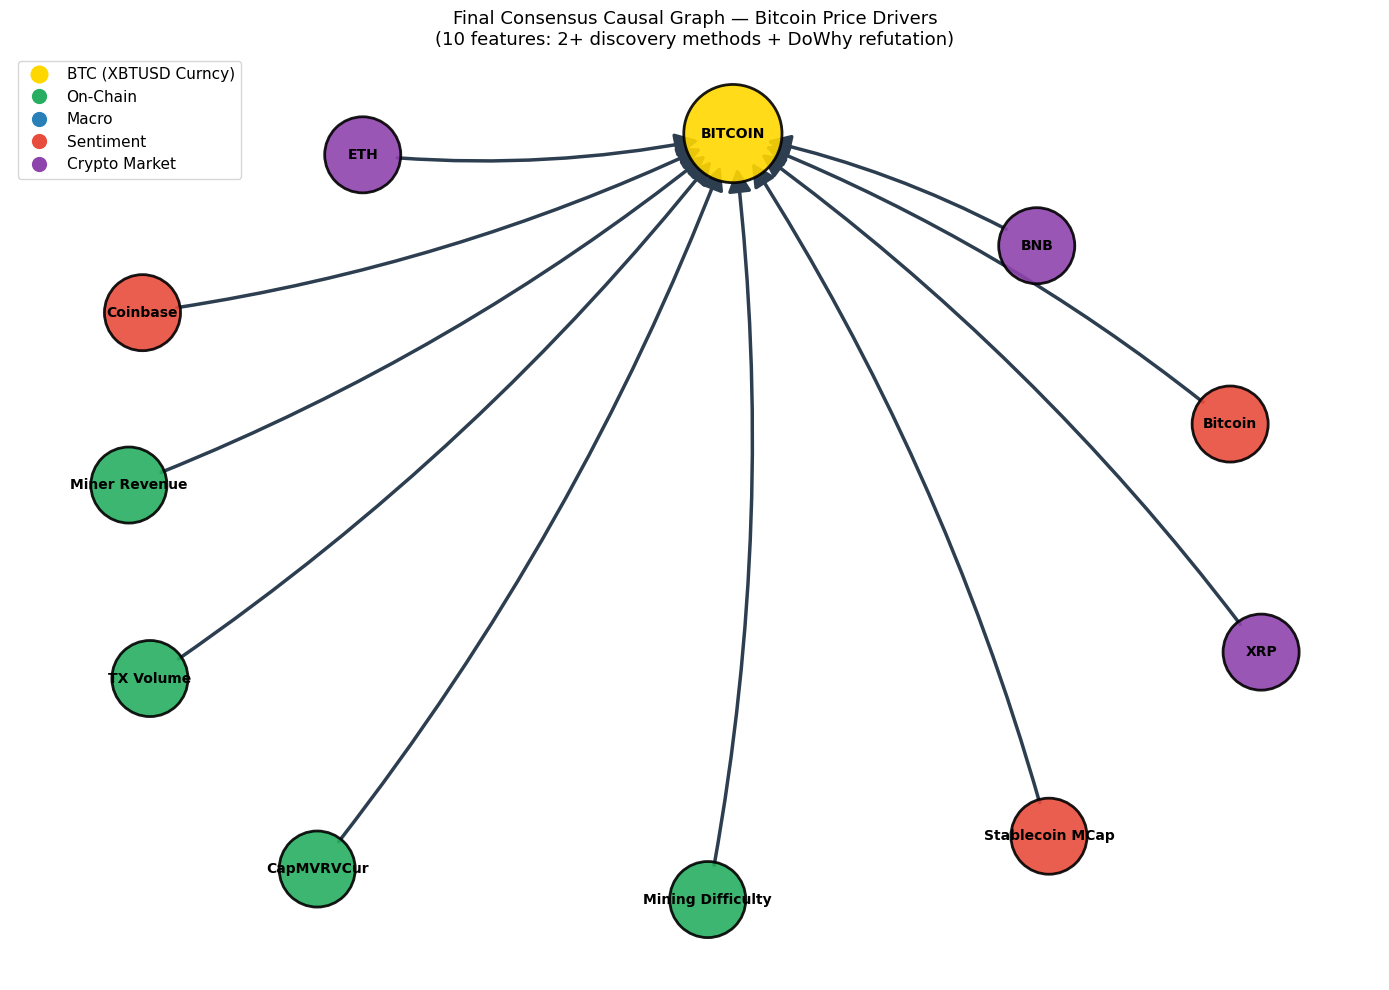

In [18]:
# ============================================================
# FINAL CONSENSUS CAUSAL GRAPH
# ============================================================

# Determine final causal set
survived_features = set(survived['Feature'].unique()) if len(survived) > 0 else set()
strong_consensus = set(comparison_df[comparison_df['Causal_Count'] >= 3]['Feature'].tolist())

# Final rule: survived DoWhy OR strong consensus (3+ methods)
final_causal = sorted((survived_features | (strong_consensus & set(consensus_features))) - BTC_DERIVED)

print(f"Final validated causal drivers of Bitcoin ({len(final_causal)}):")
for feat in final_causal:
    cat = get_category(feat)
    discovery = comparison_df[comparison_df['Feature'] == feat]['Causal_Count'].values
    n_methods = discovery[0] if len(discovery) > 0 else '?'
    dowhy_status = 'survived' if feat in survived_features else 'strong consensus'
    print(f"  {feat:30s}  ({cat:15s})  {n_methods} methods  [{dowhy_status}]")

# ---- Build and visualize final graph ----
G_final = nx.DiGraph()
G_final.add_node(BTC_TICKER)
for feat in final_causal:
    G_final.add_node(feat)
    G_final.add_edge(feat, BTC_TICKER)

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G_final, seed=42, k=2.5)

node_colors = []
node_sizes = []
for n in G_final.nodes():
    if n == BTC_TICKER:
        node_colors.append('gold')
        node_sizes.append(5000)
    else:
        cat = get_category(n)
        node_colors.append(CATEGORY_COLORS.get(cat, '#95a5a6'))
        node_sizes.append(3000)

nx.draw_networkx_nodes(G_final, pos, node_color=node_colors, node_size=node_sizes,
                       alpha=0.9, edgecolors='black', linewidths=2)
nx.draw_networkx_edges(G_final, pos, width=2.5, edge_color='#2c3e50',
                       arrows=True, arrowsize=35, arrowstyle='-|>',
                       connectionstyle='arc3,rad=0.08',
                       min_source_margin=25, min_target_margin=25)
# Shorter display names for readability
short_names = {
    'XETUSD Curncy': 'ETH',
    'XBNUSD Curncy': 'BNB', 
    'XRPUSD Curncy': 'XRP',
    'miner_revenue_usd': 'Miner Revenue',
    'mining_difficulty': 'Mining Difficulty',
    'est_tx_volume_usd': 'TX Volume',
    'total_stablecoin_mcap': 'Stablecoin MCap',
    'btc_balance_on_exchanges': 'Exchange Balance',
    'fear_and_greed': 'Fear & Greed',
    BTC_TICKER: 'BITCOIN',
}
labels = {n: short_names.get(n, n) for n in G_final.nodes()}
nx.draw_networkx_labels(G_final, pos, labels=labels, font_size=10, font_weight='bold')

legend = [
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='gold',
               markersize=14, label=f'BTC ({BTC_TICKER})'),
    plt.Line2D([0],[0], marker='o', color='w',
               markerfacecolor=CATEGORY_COLORS['On-Chain'], markersize=12, label='On-Chain'),
    plt.Line2D([0],[0], marker='o', color='w',
               markerfacecolor=CATEGORY_COLORS['Macro'], markersize=12, label='Macro'),
    plt.Line2D([0],[0], marker='o', color='w',
               markerfacecolor=CATEGORY_COLORS['Sentiment'], markersize=12, label='Sentiment'),
    plt.Line2D([0],[0], marker='o', color='w',
               markerfacecolor=CATEGORY_COLORS['Crypto Market'], markersize=12, label='Crypto Market'),
]
plt.legend(handles=legend, loc='upper left', fontsize=11)
plt.title(f'Final Consensus Causal Graph — Bitcoin Price Drivers\n'
          f'({len(final_causal)} features: 2+ discovery methods + DoWhy refutation)', fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# FINAL SUMMARY TABLE
# ============================================================
# This table maps every detected feature to:
# - Its Vaissié category
# - Results from each of the 4 discovery methods
# - DoWhy ATE estimates at 7d and 30d horizons
# - Final verdict (CAUSAL or not)

summary_rows = []
for _, row in comparison_df.iterrows():
    feat = row['Feature']
    s = {
        'Feature': feat,
        'Category': row['Category'],
        'PC': row['PC'],
        'NOTEARS': row['NOTEARS'],
        'PCMCI': row['PCMCI'],
        'Granger': row['Granger'],
        'Discovery_Count': row['Causal_Count'],
    }
    
    # Add DoWhy results if available
    if len(dowhy_all) > 0:
        feat_7d = dowhy_7d[dowhy_7d['Feature'] == feat] if len(dowhy_7d) > 0 else pd.DataFrame()
        feat_30d = dowhy_30d[dowhy_30d['Feature'] == feat] if len(dowhy_30d) > 0 else pd.DataFrame()
        s['ATE_7d'] = f"{feat_7d['ATE'].values[0]:.6f}" if len(feat_7d) > 0 else '-'
        s['ATE_30d'] = f"{feat_30d['ATE'].values[0]:.6f}" if len(feat_30d) > 0 else '-'
        
        dowhy_feat = dowhy_all[dowhy_all['Feature'] == feat]
        if len(dowhy_feat) > 0:
            best = dowhy_feat.sort_values('Survives', ascending=False).iloc[0]
            s['Refutation'] = best['Refutations_Passed']
        else:
            s['Refutation'] = '-'
    else:
        s['ATE_7d'] = '-'
        s['ATE_30d'] = '-'
        s['Refutation'] = '-'
    
    s['FINAL'] = 'CAUSAL' if feat in final_causal else ''
    summary_rows.append(s)

summary_df = pd.DataFrame(summary_rows).sort_values(
    ['FINAL', 'Discovery_Count'], ascending=[True, False]
)

print("FINAL SUMMARY — Causal Drivers of Bitcoin")
print("=" * 130)
print(summary_df.to_string(index=False))

# Category breakdown
print("\n" + "=" * 60)
print("CATEGORY BREAKDOWN of validated causal features:")
print("=" * 60)
for cat in ['On-Chain', 'Macro', 'Sentiment', 'Crypto Market']:
    cat_final = [f for f in final_causal if get_category(f) == cat]
    if cat_final:
        print(f"  {cat} ({len(cat_final)}): {cat_final}")
    else:
        print(f"  {cat}: none")

FINAL SUMMARY — Causal Drivers of Bitcoin
              Feature      Category    PC NOTEARS        PCMCI       Granger  Discovery_Count    ATE_7d   ATE_30d Refutation  FINAL
       TFC2RLFS Index         Macro               cause(lag=0)       reverse                1         -         -          -       
       fear_and_greed     Sentiment               cause(lag=1)       reverse                1         -         -          -       
            VIX Index         Macro               cause(lag=0)                              1         -         -          -       
                TxCnt      On-Chain               cause(lag=3)       reverse                1         -         -          -       
            AdrActCnt      On-Chain               cause(lag=1)       reverse                1         -         -          -       
              SplyCur      On-Chain               cause(lag=0)                              1         -         -          -       
            RTY Index         Macr

## Conclusion

### Methodology: López de Prado's 3-Step Framework Applied

1. **Phenomenological step (Section 1):** We documented statistical associations between BTC and 25+ features across Vaissié's three pillars. Stationarity was ensured via ADF+KPSS tests with adaptive transforms (differencing, log-returns, pct_change). This establishes the *observational* basis without causal claims.

2. **Theoretical step (Section 2):** We proposed causal structures using 4 complementary methods — PC Algorithm (constraint-based), NOTEARS (continuous optimization), PCMCI (temporal), and Granger (predictive). Features detected by 2+ methods were flagged as consensus causal candidates. The multi-method approach protects against each method's individual blind spots.

3. **Falsification step (Section 3):** We tested causal claims using DoWhy's backdoor linear regression at 7-day and 30-day horizons. Three refutation tests (placebo, random common cause, data subset) validated robustness. Only features passing 2/3 refutations or with strong discovery consensus (3+ methods) were retained.

### Mapping to Vaissié's Categories

Per Vaissié (2021), the relative importance of each pillar varies by horizon:
- **Short-term (7d):** Sentiment and technical factors should dominate
- **Medium-term (30d):** On-chain fundamentals (MVRV, hash rate) gain importance
- **Long-term:** Macro factors (rates, liquidity) become primary drivers

The DoWhy results at 7d vs 30d horizons allow us to test this hypothesis directly: do the ATE values shift in favor of on-chain/macro features at longer horizons?

### Limitations

- **Linear assumptions:** PC (Fisher-Z), NOTEARS, Granger, and DoWhy's linear regression all assume linear relationships. Non-linear causal mechanisms (e.g., threshold effects) may be missed.
- **Temporal resolution trade-off:** All causal discovery methods use weekly resampling (required for Google Trends compatibility). This reduces noise but loses intra-week dynamics. Granger tests use daily stationary data, providing finer temporal resolution but only for pairwise relationships.
- **Confounder specification:** The set of confounders in DoWhy is manually specified. Unmeasured confounders (regulatory news, whale activity, social media virality) cannot be controlled for.
- **Stationarity transforms:** Differencing removes trend information, which may weaken detection of long-run equilibrium relationships.
- **Limited history:** Bitcoin data starts ~2009 with meaningful liquidity only from ~2015, limiting statistical power for rare events.

### Next Steps

1. **Integrate with horizon analysis** (`horizon_analysis.py`): weight features by MDA importance across T+1/7/30 horizons
2. **Use causal features for 5-class regime prediction** (`confusion_matrix_enhanced.py`): Strong Bear / Bear / Neutral / Bull / Strong Bull
3. **Test time-varying causality**: rolling Granger tests to detect when causal relationships strengthen/weaken (regime shifts)
4. **Non-linear extensions**: use PCMCI with GPDC (Gaussian Process-based) independence test for non-linear causal detection